# Evaluasi Hybrid CAG-RAG — Wisata Danau Toba

Judul: *Analysis of Hybrid CAG-RAG for Reducing Retrieval Latency and Retrieval Inaccuracy in RAG-Based Recommendation Systems*

### Research Questions
1. **RQ1 (Latency):** Bagaimana cara menangani masalah retrieval latency pada sistem RAG?
2. **RQ2 (Relevance):** Sejauh mana perbedaan relevansi hasil retrieval Hybrid CAG-RAG vs RAG?

### Metrik

| Kategori | Metrik | RQ |
|----------|--------|----|
| Latency | Response Time, Cache Hit Rate, Speedup Factor | RQ1 |
| Relevansi | Relevance Score, Completeness | RQ2 |
| Akurasi | Exact Match, Token F1 | RQ2 |
| Kualitas | BERTScore F1 | RQ2 |
| Inaccuracy | Hallucination Rate | RQ2 |
| Statistik | Paired t-test, Cohen's d | Validasi |

### Skenario

| Skenario | Sistem | Deskripsi |
|----------|--------|-----------|
| FAQ | CAG | Query dari FAQ static cache |
| KV_Cache | CAG | Query baru via RAG, disimpan ke KV-Cache, diulang untuk ukur speedup |
| RAG | RAG | Pure retrieval, tanpa cache |

FAQ + KV_Cache = sistem CAG (Cache-Augmented Generation).

## Setup Environment

In [1]:
# Install Dependencies
%pip install -q python-dotenv sentence-transformers langchain langchain-community faiss-cpu bert-score pandas matplotlib seaborn scipy nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Setup & Imports
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from scipy import stats
import scipy
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
from bert_score import score as bert_score_fn
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv

# -- Path & env ------------------------------------------------------------
sys.path.append(os.path.abspath('../src'))
load_dotenv()

# -- Import evaluation classes dari evaluation.py -------------------------
from evaluation import QuantitativeMetrics, PerformanceEvaluator, QueryMetrics

# -- Plot style -----------------------------------------------------------
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("✅ Setup complete")
print(f"   scipy        : {scipy.__version__}")
print(f"   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded")


✅ Setup complete
   scipy        : 1.17.0
   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded


## Load Model & Encoder
- LLM: Gemini 2.5 Flash via Google REST API
- Encoder: `paraphrase-multilingual-MiniLM-L12-v2` (multilingual embedding)

In [3]:
# Load Model & Encoder (digunakan oleh seluruh notebook)
from model import GeminiChatModel
from langchain_community.embeddings import HuggingFaceEmbeddings

gemini = GeminiChatModel(model_name="gemini-2.5-flash")

encoder = HuggingFaceEmbeddings(
    model_name="paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True},
)

print("Model   : gemini-2.5-flash")
print(f"API keys: {len(gemini.api_keys)}")
print("Encoder : paraphrase-multilingual-MiniLM-L12-v2")


🔍 Initializing Gemini API: gemini-2.5-flash
🔑 API keys available: 1
⏱️ Rate limit protection: 5s between requests
🔄 Context-based fallback: ENABLED


C:\Users\lenovo\AppData\Local\Temp\ipykernel_28648\2261799897.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  encoder = HuggingFaceEmbeddings(


Model   : gemini-2.5-flash
API keys: 1
Encoder : paraphrase-multilingual-MiniLM-L12-v2


In [4]:
# ============================================================
# QUICK TEST — Gemini 2.5 Flash API
# Jalankan cell ini SEBELUM cell lainnya untuk memastikan
# API key valid dan gemini-2.5-flash dapat merespons.
# Cell ini berdiri sendiri — tidak butuh cell sebelumnya.
# ============================================================
import sys, os, io, contextlib
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "src"))
sys.path.insert(0, "../src")

from dotenv import load_dotenv
load_dotenv("../.env")

from model import GeminiChatModel

print("=" * 50)
print("Quick Test: Gemini 2.5 Flash API")
print("=" * 50)

gemini_test = GeminiChatModel(model_name="gemini-2.5-flash")

_test_prompt = "Sebutkan satu tempat wisata terkenal di Danau Toba. Jawab dalam 1-2 kalimat."

_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    _resp = gemini_test._call_gemini_api(_test_prompt, max_tokens=100)
_log = _buf.getvalue()

active_model = None
for _line in _log.splitlines():
    if "Response from" in _line:
        active_model = _line.split("Response from")[-1].strip().split()[0]
        break

print(f"\nHasil:")
print(f"  API key     : {len(gemini_test.api_keys)} key ditemukan")
print(f"  Model aktif : {active_model or 'tidak terdeteksi'}")
print(f"  Response    : {repr(_resp[:80]) if _resp else None}")

if _resp and active_model and "2.5-flash" in active_model:
    print("\nSIAP: gemini-2.5-flash berjalan normal, lanjutkan ke cell berikutnya")
elif _resp and active_model:
    print(f"\nFALLBACK: yang merespons {active_model} (bukan 2.5-flash)")
    print("  Kemungkinan: quota 2.5-flash habis atau key belum valid")
else:
    print("\nGAGAL: API tidak merespons")
    print("  Cek: GEMINI_API_KEY di .env sudah benar?")
    print(_log)


Quick Test: Gemini 2.5 Flash API
🔍 Initializing Gemini API: gemini-2.5-flash
🔑 API keys available: 1
⏱️ Rate limit protection: 5s between requests
🔄 Context-based fallback: ENABLED

Hasil:
  API key     : 1 key ditemukan
  Model aktif : gemini-2.5-flash
  Response    : 'Salah satu tempat wisata terkenal di Danau Toba adalah **Pulau Samosir**. Pulau '

SIAP: gemini-2.5-flash berjalan normal, lanjutkan ke cell berikutnya


## Build Knowledge Base

In [5]:
# Load Documents & Build Vector DB
# ─────────────────────────────────────────────────────────────
# Optimasi: simpan index FAISS ke disk setelah build pertama.
# Pada run berikutnya langsung load dari disk (jauh lebih cepat).
# Jika PDF berubah, hapus folder database/faiss_index/ untuk rebuild.

import time as _t_mod

tourism_dir      = os.path.abspath('../database/documents')
faiss_index_path = os.path.abspath('../database/faiss_index')

pdf_files = []
if os.path.exists(tourism_dir):
    pdf_files = [os.path.join(tourism_dir, f)
                 for f in sorted(os.listdir(tourism_dir)) if f.endswith('.pdf')]

# ── A. Load cached index jika sudah ada ────────────────────
if os.path.exists(os.path.join(faiss_index_path, 'index.faiss')):
    print(f"📂 Memuat FAISS index dari cache …")
    _ta = _t_mod.time()
    faiss_db = FAISS.load_local(faiss_index_path, encoder,
                                allow_dangerous_deserialization=True)
    # Load docs juga agar tersedia untuk pdf_qa generation
    pages = [p for pdf in pdf_files for p in PyPDFLoader(pdf).load()]
    docs  = RecursiveCharacterTextSplitter(
                chunk_size=768, chunk_overlap=100
            ).split_documents(pages) if pages else []
    print(f"✅ Index dimuat dalam {_t_mod.time()-_ta:.1f}s")
    print(f"   {len(pdf_files)} PDFs → {len(docs)} chunks  ({tourism_dir})")

# ── B. Build dari PDF + simpan ke disk ─────────────────────
elif pdf_files:
    print(f"⏳ Membangun FAISS index dari {len(pdf_files)} PDF …")
    pages = [p for pdf in pdf_files for p in PyPDFLoader(pdf).load()]
    docs  = RecursiveCharacterTextSplitter(
                chunk_size=768, chunk_overlap=100
            ).split_documents(pages)
    print(f"   {len(pages)} halaman → {len(docs)} chunks")

    # Embed bertahap dengan progress agar tidak freeze
    BATCH = 64
    texts     = [d.page_content for d in docs]
    metadatas = [d.metadata      for d in docs]
    all_embeddings = []

    print(f"   Embedding {len(texts)} chunks (batch={BATCH}) …")
    _ta = _t_mod.time()
    for i in range(0, len(texts), BATCH):
        batch = texts[i : i + BATCH]
        embs  = encoder.embed_documents(batch)
        all_embeddings.extend(embs)
        done = min(i + BATCH, len(texts))
        print(f"   [{done:>4}/{len(texts)}]", end='\r')

    print(f"\n   Embedding selesai dalam {_t_mod.time()-_ta:.1f}s")

    # Build FAISS dari pre-computed embeddings
    faiss_db = FAISS.from_embeddings(
        list(zip(texts, all_embeddings)),
        encoder,
        metadatas=metadatas,
    )

    # Simpan ke disk untuk run berikutnya
    os.makedirs(faiss_index_path, exist_ok=True)
    faiss_db.save_local(faiss_index_path)
    print(f"   💾 Index disimpan ke {faiss_index_path}")
    print(f"\n✅ {len(pdf_files)} PDFs → {len(docs)} chunks")
    for p in pdf_files:
        print(f"   - {os.path.basename(p)}")

# ── C. Tidak ada PDF ────────────────────────────────────────
else:
    docs     = []
    faiss_db = None
    print(f"⚠️  Tidak ada PDF di {tourism_dir}")
    print("   Letakkan file PDF wisata ke folder database/documents/")

📂 Memuat FAISS index dari cache …
✅ Index dimuat dalam 5.0s
   4 PDFs → 224 chunks  (d:\Semester 8\TA II\Implementasi\database\documents)


## Setup CAG System

In [6]:
# Setup CAG System (Hybrid CAG-RAG)
try:
    from hybrid_system import CAGSystem   # nama modul yang benar
    cag = CAGSystem(gemini, encoder)
    if pdf_files:
        cag.load_documents(pdf_files, use_summaries=False)
    cag_ok = True
    print("✅ CAG System (Hybrid CAG-RAG) ready")
    print(f"   Confirmed cache entries : {len(cag.kv_cache.cache)}")
    print(f"   Staging entries         : {len(cag.kv_cache.staging)}")
except Exception as e:
    cag_ok = False
    print(f"⚠️  CAG not available: {e}")

✅ Loaded 0 confirmed + 147 staging items
📚 Loading 4 documents for CAG...
   ✅ Loaded: data rumah makan.pdf (21 halaman)
   ✅ Loaded: hotel.pdf (29 halaman)
   ✅ Loaded: transportasi.pdf (5 halaman)
   ✅ Loaded: wisata.pdf (31 halaman)
🔍 Splitting into chunks...
📄 Loaded 86 halaman dari 4 file, split into 231 chunks
🔨 Building vector database...
📊 Building BM25 index...
   ✅ BM25 index dibangun: 231 chunks
✅ CAG ready: 231 chunks in 25.55s
✅ CAG System (Hybrid CAG-RAG) ready
   Confirmed cache entries : 0
   Staging entries         : 147


## Test Dataset

In [7]:
# === Dataset 100+100: FAQ (CAG path) + Novel Queries (RAG/KV-Cache path) ===
#
# Split desain evaluasi dua jalur (Thakur et al. 2021 BEIR; Lewis et al. 2020 RAG):
#   dataset_faq     (100) → sampel acak LANGSUNG dari 424 FAQ statis (seed=42)
#                           → akan masuk jalur CAG/FAQ cache (ctx="from_faq")
#   dataset_novel   (100) → pertanyaan novel (bukan dari FAQ cache):
#                             49 dari kuesioner pengguna nyata (representatif, Likert)
#                             51 pertanyaan generated per kategori wisata
#                           → tidak ada di FAQ → masuk KV-Cache atau RAG murni
#
# Alasan split ini: mencegah "cheating" di mana FAQ selalu mendapat cache hit 100%
#   karena pertanyaan diambil langsung dari sumber cache yang sama.
#   Dengan split ini, evaluasi menguji fairness skenario: FAQ harus ≈ 100% hit,
#   sedangkan novel queries menguji kemampuan retrieval dan generalisasi sistem.
#
# Ukuran sampel N=100 per kelompok → statistical power ≈ 0.94 pada α=0.05 (Cohen 1988)
# Ref: Thakur et al. (2021) BEIR; Lewis et al. (2020) RAG; Es et al. (2023) RAGAS

import re as _re_kw
import os as _os
import random as _random

def _extract_keywords(text: str, top_n: int = 6) -> list:
    """Ekstrak kata kunci bermakna dari teks jawaban."""
    stopwords_id = {
        'yang', 'dan', 'dari', 'untuk', 'dengan', 'adalah', 'pada',
        'atau', 'juga', 'akan', 'ini', 'itu', 'bisa', 'dapat', 'lebih',
        'telah', 'sudah', 'sedang', 'dalam', 'oleh', 'antara', 'serta',
        'maka', 'jika', 'agar', 'bagi', 'baik', 'atas', 'tersebut',
        'mereka', 'kami', 'kita', 'saya', 'anda', 'tidak', 'belum',
        'sangat', 'sekali', 'hanya', 'masih', 'sebagai', 'seperti',
        'karena', 'setiap', 'saat', 'yaitu', 'salah', 'satu', 'para',
        'menjadi', 'secara', 'hingga', 'sampai', 'melalui', 'namun',
        'tetapi', 'sehingga', 'dimana', 'ketika', 'selain', 'hampir',
        'nbsp', 'quot',
    }
    from collections import Counter as _C
    tokens = _re_kw.findall(r'[A-Za-z\u00C0-\u024F]{4,}', text)
    freq   = _C(w for w in tokens if w.lower() not in stopwords_id)
    seen   = {}
    for w in tokens:
        key = w.lower()
        if key not in seen and key not in stopwords_id:
            seen[key] = w
    top_keys = [k for k, _ in freq.most_common(top_n)]
    return [seen[k] for k in top_keys if k in seen]

# ── Part 1: dataset_faq — langsung dari faq_tourism.json (seed=42) ────────
_faq_source_path = _os.path.abspath('../database/FAQ/faq_tourism.json')
dataset_faq = []

if _os.path.exists(_faq_source_path):
    with open(_faq_source_path, 'r', encoding='utf-8') as _f:
        _faq_all = json.load(_f)

    # Filter entri yang valid (punya pertanyaan dan jawaban)
    _faq_valid = [
        x for x in _faq_all
        if x.get("question", "").strip() and x.get("answer", "").strip()
    ]

    # Sampel 100 acak dengan seed tetap untuk reproducibility
    _random.seed(42)
    _faq_sampled = _random.sample(_faq_valid, min(100, len(_faq_valid)))

    dataset_faq = [
        {
            "q":        item["question"],
            "gt":       item["answer"],
            "kw":       _extract_keywords(item["answer"]),
            "source":   "faq",
            "category": "faq",
        }
        for item in _faq_sampled
    ]
    print(f"✅ dataset_faq     : {len(dataset_faq)} queries")
    print(f"   Sumber          : faq_tourism.json ({len(_faq_valid)}/{len(_faq_all)} entri valid, seed=42)")
    print(f"   Contoh Q        : {dataset_faq[0]['q'][:65]}")
else:
    print(f"⚠️  faq_tourism.json tidak ditemukan di: {_faq_source_path}")

# ── Part 2: dataset_novel (sebelumnya dataset_nonfaq_100) ─────────────────
_old_nonfaq_path = _os.path.abspath('../database/FAQ/dataset_nonfaq_100.json')
_novel_path      = _os.path.abspath('../database/FAQ/dataset_queries_novel.json')

# Backward compat: rename file lama jika belum di-rename
if _os.path.exists(_old_nonfaq_path) and not _os.path.exists(_novel_path):
    _os.rename(_old_nonfaq_path, _novel_path)
    print(f"📁 Renamed: dataset_nonfaq_100.json → dataset_queries_novel.json")

nonfaq_ds_path = _novel_path
dataset_nonfaq = []

if _os.path.exists(nonfaq_ds_path):
    with open(nonfaq_ds_path, 'r', encoding='utf-8') as _f:
        _nonfaq_raw = json.load(_f)

    # Cek apakah GT perlu di-generate
    _missing_gt = [i for i, x in enumerate(_nonfaq_raw) if not x.get("answer", "").strip()]

    if _missing_gt:
        print(f"\n⏳ {len(_missing_gt)} entri novel queries belum memiliki GT → generating via Gemini...")
        print("   (hanya sekali; hasil disimpan ke dataset_queries_novel.json)")
        for _idx in _missing_gt:
            _q = _nonfaq_raw[_idx]["question"]
            _prompt = (
                "Kamu adalah asisten wisata Danau Toba. Jawab pertanyaan berikut "
                "dalam 1–3 kalimat ringkas dan faktual dalam Bahasa Indonesia.\n\n"
                f"Pertanyaan: {_q}"
            )
            try:
                _ans = gemini._call_gemini_api(_prompt, max_tokens=200)
                if _ans and len(_ans.strip()) >= 20:
                    _nonfaq_raw[_idx]["answer"] = _ans.strip()
                    if (_idx + 1) % 10 == 0:
                        print(f"  [{_idx+1:>3}/100] OK — {_q[:55]}")
            except Exception as _e:
                print(f"  [{_idx+1:>3}/100] error: {_e}")
            time.sleep(1.5)

        with open(nonfaq_ds_path, 'w', encoding='utf-8') as _f:
            json.dump(_nonfaq_raw, _f, ensure_ascii=False, indent=2)
        print(f"  💾 GT disimpan ke dataset_queries_novel.json")

    # Hanya ambil yang sudah punya GT
    dataset_nonfaq = [
        {
            "q":        item["question"],
            "gt":       item.get("answer", ""),
            "kw":       _extract_keywords(item.get("answer", "")),
            "source":   item.get("source", "novel"),
            "category": item.get("category", "general"),
        }
        for item in _nonfaq_raw if item.get("answer", "").strip()
    ]

    from collections import Counter as _Counter
    _src_cnt = _Counter(item.get("source", "") for item in _nonfaq_raw)
    _cat_cnt = _Counter(item.get("category", "") for item in _nonfaq_raw)
    print(f"\n✅ dataset_novel   : {len(dataset_nonfaq)} queries")
    print(f"   - kuesioner nyata : {_src_cnt.get('kuesioner', 0)}")
    print(f"   - generated       : {_src_cnt.get('generated', 0)}")
    print(f"   Kategori          : {dict(_cat_cnt)}")
else:
    print(f"⚠️  dataset_queries_novel.json tidak ditemukan di: {nonfaq_ds_path}")

# ── Part 3: Gabung & Ringkas ──────────────────────────────────────────────
dataset = dataset_faq + dataset_nonfaq

print(f"\n{'='*60}")
print(f"📊 DATASET SUMMARY — 100 FAQ + 100 Novel Queries = 200 Total")
print(f"{'='*60}")
print(f"  dataset_faq    (CAG/FAQ path)   : {len(dataset_faq):>4} queries")
print(f"  dataset_novel  (RAG/KV path)    : {len(dataset_nonfaq):>4} queries")
print(f"  Total                           : {len(dataset):>4} queries")
print(f"{'='*60}")
print(f"  Statistical power (N=100, α=0.05, d=0.3): ~0.94  (Cohen 1988)")
print(f"  Estimasi waktu evaluasi: ~{len(dataset)*20//60} menit {len(dataset)*20%60} detik")
print(f"\n  Alur evaluasi yang diharapkan:")
print(f"  - dataset_faq    → hit FAQ cache   → source=cag_cache, ctx=from_faq")
print(f"  - dataset_novel  → tidak di FAQ    → KV-Cache/RAG retrieval")


✅ dataset_faq     : 100 queries
   Sumber          : faq_tourism.json (424/424 entri valid, seed=42)
   Contoh Q        : Berapa lama waktu perjalanan dari Hotel O Balige City Near Tugu J

✅ dataset_novel   : 100 queries
   - kuesioner nyata : 49
   - generated       : 51
   Kategori          : {'hotel_penginapan': 13, 'wisata_umum': 8, 'wisata_spesifik': 11, 'preferensi': 8, 'kuliner': 9, 'wisata_budaya': 7, 'transportasi': 8, 'penginapan_luar_balige': 8, 'aktivitas_petualangan': 8, 'informasi_praktis': 7, 'event_festival': 6, 'makanan_tradisional': 7}

📊 DATASET SUMMARY — 100 FAQ + 100 Novel Queries = 200 Total
  dataset_faq    (CAG/FAQ path)   :  100 queries
  dataset_novel  (RAG/KV path)    :  100 queries
  Total                           :  200 queries
  Statistical power (N=100, α=0.05, d=0.3): ~0.94  (Cohen 1988)
  Estimasi waktu evaluasi: ~66 menit 40 detik

  Alur evaluasi yang diharapkan:
  - dataset_faq    → hit FAQ cache   → source=cag_cache, ctx=from_faq
  - dataset_novel 

## Inference Functions
- `rag_infer()` — retrieve + generate, tanpa cache
- `cag_infer()` — cache-first, fallback ke RAG jika miss

In [8]:
# === Inference Functions ===
#
# RAG  : use_cache=False  → selalu retrieve dari vector DB + generate (tidak pakai cache)
# CAG  : use_cache=True   → cek cache dulu; jika hit → langsung return,
#                           jika miss → retrieve + generate + simpan ke cache
#
# Kedua fungsi menggunakan cag.get_response() yang sama, perbedaannya hanya pada
# flag use_cache. Ini memastikan evaluasi RAG vs CAG apples-to-apples.

def rag_infer(q: str, k: int = 5) -> dict:
    """RAG pure: selalu retrieve + generate, tanpa cache."""
    if not cag_ok:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False}
    t0 = time.time()
    r  = cag.get_response(q, k=k, use_cache=False)
    return {
        'resp':  r.get('response', ''),
        'ctx':   r.get('context',  ''),
        'time':  time.time() - t0,
        'cache': False,
    }


def cag_infer(q: str, k: int = 5) -> dict:
    """CAG: cache-first, lalu RAG jika miss."""
    if not cag_ok:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False}
    t0 = time.time()
    r  = cag.get_response(q, k=k, use_cache=True)
    return {
        'resp':  r.get('response',   ''),
        'ctx':   r.get('context',    ''),
        'time':  time.time() - t0,
        'cache': r.get('cache_used', False),
    }


print("✅ Inference ready")
print("   RAG : use_cache=False  (pure retrieval+generate)")
print("   CAG : use_cache=True   (cache-first → RAG fallback)")

✅ Inference ready
   RAG : use_cache=False  (pure retrieval+generate)
   CAG : use_cache=True   (cache-first → RAG fallback)


## Evaluation Metrics

| Metrik | Deskripsi |
|--------|-----------|
| BERTScore F1 | Semantic similarity response vs ground truth |
| Completeness | % keywords yang muncul di response |
| Hallucination | % kalimat response tanpa grounding di context |
| RAG Recall | % keywords ditemukan di retrieved docs |
| EIR | % context words yang digunakan di response |

In [9]:
# === Metrics Functions ===
# Menggunakan QuantitativeMetrics dari evaluation.py sebagai backbone

import re as _re
from collections import Counter
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
qm = QuantitativeMetrics()   # instance dari evaluation.py

# --------------------------------------------------------------------------
# 1. BERTScore F1  (semantic similarity response vs ground truth)
# --------------------------------------------------------------------------
def bertscore_f1(preds: list, refs: list) -> float:
    if not preds or not refs or not preds[0] or not refs[0]:
        return 0.0
    try:
        P, R, F = bert_score_fn(preds, refs, lang='id', verbose=False)
        return float(F.mean().item())
    except Exception as e:
        print(f"  ⚠️  BERTScore error: {e}")
        return 0.0

# --------------------------------------------------------------------------
# 2. Accuracy: Exact Match (EM) + Token F1  [§3.11.2.5 Akurasi Informasi]
#    Standard SQuAD-style metrics — Rajpurkar et al. (2016)
# --------------------------------------------------------------------------
def _normalize_text(s: str) -> str:
    """Lower, strip punctuation, remove articles."""
    s = s.lower()
    s = _re.sub(r'\b(a|an|the|dan|yang|di|ke|dari|untuk|adalah)\b', ' ', s)
    s = _re.sub(r'[^a-z0-9\s]', ' ', s)
    return ' '.join(s.split())

def exact_match(pred: str, gold: str) -> float:
    return 1.0 if _normalize_text(pred) == _normalize_text(gold) else 0.0

def token_f1(pred: str, gold: str) -> float:
    pred_tokens = _normalize_text(pred).split()
    gold_tokens = _normalize_text(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return (2 * precision * recall) / (precision + recall)

def accuracy_score(resp: str, gt: str) -> dict:
    return {'em': exact_match(resp, gt), 'token_f1': token_f1(resp, gt)}

# --------------------------------------------------------------------------
# 3. Completeness  (% keywords ground truth yang muncul di response)
# --------------------------------------------------------------------------
def completeness(resp: str, kw: list) -> float:
    result = qm.calculate_completeness(resp, kw)
    return result["completeness"]

# --------------------------------------------------------------------------
# 4. Hallucination Rate — 3-Tier Faithfulness  (RAGAS-inspired)
#
#    Tier 0 (Guard):    ctx ="from_faq" atau kosong/pendek < 20 char
#                       → float('nan')  [N/A: FAQ adalah ground truth itu sendiri]
#    Tier 1 (Semantic): cosine similarity encoder embeddings
#                       → hallucination = 1 − cosine_sim  [0, 1]
#    Tier 2 (Bigram):   bigram overlap sebagai fallback bila encoder gagal
#                       → hallucination = 1 − bigram_overlap  [0, 1]
#
#    Ref: Es et al. (2023) RAGAS — https://arxiv.org/abs/2309.15217
#         Guo et al. (2022) Prompt Cache — cosine faithfulness measure
# --------------------------------------------------------------------------
def hallucination(resp: str, ctx: str) -> float:
    """
    Returns hallucination score ∈ [0.0, 1.0] or float('nan').
    0.0  = jawaban sepenuhnya ter-grounded di context.
    1.0  = jawaban sepenuhnya hallucination.
    NaN  = tidak berlaku (FAQ path — context adalah jawaban itu sendiri).
    """
    # Tier 0 — Guard
    _ctx = (ctx or "").strip()
    if not _ctx or _ctx == "from_faq" or len(_ctx) < 20:
        return float('nan')

    # Tier 1 — Semantic cosine via multilingual encoder
    try:
        resp_emb = np.array(encoder.embed_query(resp[:512]))
        ctx_emb  = np.array(encoder.embed_query(_ctx[:512]))
        norm     = np.linalg.norm(resp_emb) * np.linalg.norm(ctx_emb)
        cos_sim  = float(np.dot(resp_emb, ctx_emb) / (norm + 1e-9))
        return float(np.clip(1.0 - cos_sim, 0.0, 1.0))
    except Exception:
        pass  # fallback ke Tier 2

    # Tier 2 — Bigram overlap fallback
    def _bigrams(text: str) -> set:
        tokens = _re.sub(r'[^\w\s]', ' ', text.lower()).split()
        return set(zip(tokens[:-1], tokens[1:])) if len(tokens) > 1 else set()

    resp_bg = _bigrams(resp)
    ctx_bg  = _bigrams(_ctx)
    if not resp_bg:
        return 0.0
    overlap = len(resp_bg & ctx_bg) / len(resp_bg)
    return float(1.0 - overlap)

# --------------------------------------------------------------------------
# 5. Relevance / Irrelevancy Score  [§3.11.2.3 Relevansi Jawaban]
# --------------------------------------------------------------------------
def relevance_score(resp: str, query: str) -> float:
    result = qm.calculate_irrelevancy_score(resp, query)
    return result["relevance_score"]

def irrelevancy(resp: str, query: str) -> float:
    result = qm.calculate_irrelevancy_score(resp, query)
    return result["irrelevancy_score"]

# --------------------------------------------------------------------------
# 6. RAG Recall  (% keywords ground truth ada di context yang di-retrieve)
#
#    Tier 0 Guard: ctx="from_faq" atau pendek < 20 char
#    → float('nan')  [N/A: FAQ tidak melakukan retrieval nyata]
#    Berlaku sama seperti hallucination() — Es et al. (2023) RAGAS convention
# --------------------------------------------------------------------------
def rag_recall(ctx: str, kw: list) -> float:
    # Tier 0 — Guard: FAQ path tidak melakukan retrieval nyata
    _ctx = (ctx or "").strip()
    if not _ctx or _ctx == "from_faq" or len(_ctx) < 20:
        return float('nan')
    if not kw:
        return 0.0
    ctx_lower = _ctx.lower()
    return sum(k.lower() in ctx_lower for k in kw) / len(kw)

# --------------------------------------------------------------------------
# 7. EIR – Effective Information Rate
#
#    Tier 0 Guard: ctx="from_faq" atau pendek < 20 char
#    → float('nan')  [N/A: FAQ tidak ada retrieved context untuk diukur]
# --------------------------------------------------------------------------
def eir(ctx: str, resp: str) -> float:
    # Tier 0 — Guard: FAQ path tidak ada retrieved context
    _ctx = (ctx or "").strip()
    if not _ctx or _ctx == "from_faq" or len(_ctx) < 20:
        return float('nan')
    if not resp:
        return 0.0
    cw = {w.lower() for w in _ctx.split()  if len(w) > 4}
    rw = {w.lower() for w in resp.split() if len(w) > 4}
    return len(cw & rw) / len(cw) if cw else 0.0

# --------------------------------------------------------------------------
# 8. Statistical helpers — NaN-aware
# --------------------------------------------------------------------------
def paired_ttest(a: list, b: list):
    """
    Paired t-test yang aman terhadap NaN.
    Skips posisi i di mana salah satu nilai a[i] atau b[i] adalah NaN.
    Returns (t_stat, p_value, n_valid).
    """
    pairs = [
        (x, y) for x, y in zip(a, b)
        if not (isinstance(x, float) and np.isnan(x))
        and not (isinstance(y, float) and np.isnan(y))
    ]
    if len(pairs) < 2:
        return (float('nan'), float('nan'), len(pairs))
    va, vb = zip(*pairs)
    t, p = stats.ttest_rel(list(va), list(vb))
    return (round(float(t), 4), round(float(p), 4), len(pairs))

def cohens_d(a: list, b: list) -> float:
    """Cohen's d — NaN-aware, mengabaikan pasangan dengan NaN."""
    pairs = [
        (x, y) for x, y in zip(a, b)
        if not (isinstance(x, float) and np.isnan(x))
        and not (isinstance(y, float) and np.isnan(y))
    ]
    if len(pairs) < 2:
        return float('nan')
    va, vb = zip(*pairs)
    diff = [x - y for x, y in zip(va, vb)]
    return round(float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-9)), 4)

print("✅ Metrics ready — 3-Tier Hallucination + NaN-aware RAG Recall & EIR")
print("   bertscore_f1  | completeness  | hallucination (3-tier) | relevance_score")
print("   exact_match   | token_f1      | rag_recall (NaN-guard) | eir (NaN-guard)")
print("   paired_ttest  | cohens_d      (keduanya NaN-aware)")
print()
print("   NaN guard berlaku pada:")
print("     hallucination() : ctx='from_faq' atau < 20 char  → NaN")
print("     rag_recall()    : ctx='from_faq' atau < 20 char  → NaN")
print("     eir()           : ctx='from_faq' atau < 20 char  → NaN")
print("   Semua rata-rata dan t-test mengabaikan NaN secara otomatis.")


✅ Metrics ready — 3-Tier Hallucination + NaN-aware RAG Recall & EIR
   bertscore_f1  | completeness  | hallucination (3-tier) | relevance_score
   exact_match   | token_f1      | rag_recall (NaN-guard) | eir (NaN-guard)
   paired_ttest  | cohens_d      (keduanya NaN-aware)

   NaN guard berlaku pada:
     hallucination() : ctx='from_faq' atau < 20 char  → NaN
     rag_recall()    : ctx='from_faq' atau < 20 char  → NaN
     eir()           : ctx='from_faq' atau < 20 char  → NaN
   Semua rata-rata dan t-test mengabaikan NaN secara otomatis.


## Eksekusi 3 Skenario

| Skenario | Sistem | Proses |
|----------|--------|--------|
| FAQ | CAG | FAQ cache hit langsung |
| KV_Cache | CAG | RAG → simpan KV-Cache → query ulang |
| RAG | RAG | Pure retrieval, tanpa cache |

In [10]:
# Evaluation loop: RAG vs Hybrid CAG-RAG
#
# Three test paths:
#   FAQ      (CAG) - query already in static FAQ cache -> immediate hit
#   KV_Cache (CAG) - new query goes through RAG, cached, then repeated to measure speedup
#   RAG            - pure retrieval, no cache

rag_res = []
cag_res = []
scenario_results = {'FAQ': [], 'KV_Cache': [], 'RAG': []}

def _compute_metrics(resp, ctx, gt, kw, query):
    """Hitung semua metrik per-query dan kembalikan sebagai dict."""
    return {
        'bert':   bertscore_f1([resp], [gt]) if resp and gt else 0.0,
        'comp':   completeness(resp, kw),
        'tf1':    token_f1(resp, gt),
        'rel':    relevance_score(resp, query),
        'hall':   hallucination(resp, ctx),   # NaN untuk FAQ path (Tier 0)
        'irr':    irrelevancy(resp, query),
        'recall': rag_recall(ctx, kw),        # NaN untuk FAQ path (Tier 0)
        'eir':    eir(ctx, resp),             # NaN untuk FAQ path (Tier 0)
    }

print(f"Evaluating {len(dataset)} queries  |  RAG vs Hybrid CAG-RAG")
print("-" * 60)

for i, d in enumerate(dataset, 1):
    q = d['q']
    print(f"[{i:>2}/{len(dataset)}] {q[:70]}")

    # ── RAG path: pure retrieval, no cache ────────────────────────────────
    r = rag_infer(q)
    r.update({'gt': d['gt'], 'kw': d['kw'], 'query': q, 'scenario': 'RAG'})
    r['metrics'] = _compute_metrics(
        r.get('resp', ''), r.get('ctx', ''), d['gt'], d['kw'], q
    )
    rag_res.append(r)
    scenario_results['RAG'].append(r)
    print(f"  RAG       : {r['time']:.2f}s  ctx={len(r['ctx'])} chars")

    time.sleep(3)

    if cag_ok:
        # ── CAG path: FAQ cache or KV-Cache fallback ───────────────────────
        c = cag_infer(q)
        c.update({'gt': d['gt'], 'kw': d['kw'], 'query': q})

        if c['cache']:
            # First call is a cache hit -> FAQ static cache path
            c['scenario'] = 'FAQ'
            c['metrics'] = _compute_metrics(
                c.get('resp', ''), c.get('ctx', ''), d['gt'], d['kw'], q
            )
            scenario_results['FAQ'].append(c)
            cag_res.append(c)
            print(f"  CAG [FAQ] : {c['time']:.2f}s  cache=HIT (static FAQ)")
        else:
            # First call is a miss -> RAG retrieval -> stored in KV-Cache
            # Repeat same query to confirm KV-Cache hit and measure speedup
            c['scenario'] = 'KV_Cache_first'
            print(f"  CAG [miss]: {c['time']:.2f}s  cache=MISS -> stored to KV-Cache")

            time.sleep(2)
            c2 = cag_infer(q)
            c2.update({'gt': d['gt'], 'kw': d['kw'], 'query': q, 'scenario': 'KV_Cache'})
            c2['metrics'] = _compute_metrics(
                c2.get('resp', ''), c2.get('ctx', ''), d['gt'], d['kw'], q
            )

            speedup_val = round(c['time'] / c2['time'], 2) if c2['time'] > 0 else 0
            scenario_results['KV_Cache'].append({
                'query':         q,
                'kw':            d['kw'],
                'gt':            d['gt'],
                'resp':          c2.get('resp', ''),
                'ctx':           c2.get('ctx', ''),
                'time':          round(c2['time'], 3),
                'cache':         c2.get('cache', False),
                'first_time':    round(c['time'], 3),
                'second_time':   round(c2['time'], 3),
                'speedup':       speedup_val,
                'cache_hit_2nd': c2.get('cache', False),
                'metrics':       c2['metrics'],   # simpan metrik warm call
            })

            # Gunakan c2 (warm/HIT) sebagai representasi CAG, bukan c (cold/MISS)
            cag_res.append(c2)
            print(f"  CAG [KV$] : {c2['time']:.2f}s  "
                  f"cache={'HIT' if c2.get('cache') else 'MISS'}  speedup={speedup_val:.2f}x")

    if i < len(dataset):
        time.sleep(3)

print("-" * 60)
print(f"Done.  RAG={len(rag_res)}  CAG={len(cag_res)}")
print(f"  FAQ      path : {len(scenario_results['FAQ'])} hits")
print(f"  KV_Cache path : {len(scenario_results['KV_Cache'])} pairs tested")
print(f"  RAG      path : {len(scenario_results['RAG'])} queries")


Evaluating 200 queries  |  RAG vs Hybrid CAG-RAG
------------------------------------------------------------
[ 1/200] Berapa lama waktu perjalanan dari Hotel O Balige City Near Tugu Juara 
🔍 Retrieval: 5 raw → 5 lolos threshold (hybrid ≥ 0.3) → 0 exact-place match → 5 after dedup | best: hybrid=0.61 (vektor=0.46, bm25=0.84)
📄 Retrieved 5 chunks, context: 3300 chars
🎯 Intent: tourism | Query: Berapa lama waktu perjalanan dari Hotel O Balige C...
📡 gemini-2.5-flash (maxTokens=4096), attempt 1...
✅ Response from gemini-2.5-flash (345 chars, reason: STOP)
⚠️ Invalid response detected with context available — retrying with stronger prompt...
🎯 Intent: tourism | Query: Berapa lama waktu perjalanan dari Hotel O Balige C...
⏳ Rate limit protection: waiting 2.4s...
📡 gemini-2.5-flash (maxTokens=4096), attempt 1...
✅ Response from gemini-2.5-flash (365 chars, reason: STOP)
🔄 Retry response: 365 chars
  RAG       : 8.21s  ctx=3300 chars
✅ Cache STAGING: Berapa lama waktu perjalanan dari Hotel O 

## Calculate & Display Results

In [11]:
# 📊 CALCULATE ALL METRICS
# Menghasilkan dict metrik lengkap per query & agregat

def calc_metrics(res: list) -> dict:
    """Hitung semua metrik untuk setiap query lalu agregasikan."""
    m = {
        'time': [], 'cache': [],
        'bert': [], 'comp': [], 'hall': [], 'irr': [], 'rel': [],
        'recall': [], 'eir': [],
        'em': [], 'token_f1': [],
        'per_query': []
    }

    for r in res:
        resp  = r.get('resp', '')
        ctx   = r.get('ctx',  '')
        gt    = r.get('gt',   '')
        kw    = r.get('kw',   [])
        query = r.get('query', '')

        t      = r['time']
        c_hit  = 1 if r.get('cache') else 0
        bs     = bertscore_f1([resp], [gt]) if resp and gt else 0.0
        comp   = completeness(resp, kw)
        hall   = hallucination(resp, ctx)   # NaN untuk FAQ path (Tier 0 Guard)
        rel    = relevance_score(resp, query)
        irr    = irrelevancy(resp, query)
        recall = rag_recall(ctx, kw)
        e      = eir(ctx, resp)
        acc    = accuracy_score(resp, gt)

        m['time'].append(t);      m['cache'].append(c_hit)
        m['bert'].append(bs);     m['comp'].append(comp)
        m['hall'].append(hall);   m['irr'].append(irr)
        m['rel'].append(rel);     m['recall'].append(recall)
        m['eir'].append(e)
        m['em'].append(acc['em']); m['token_f1'].append(acc['token_f1'])

        _hall_display = round(hall, 4) if not (isinstance(hall, float) and np.isnan(hall)) else float('nan')
        m['per_query'].append({
            'query':     query[:60],
            'time':      round(t,      3),
            'cache':     bool(c_hit),
            'bert':      round(bs,     4),
            'comp':      round(comp,   4),
            'hall':      _hall_display,
            'relevance': round(rel,    4),
            'irr':       round(irr,    4),
            'recall':    round(recall, 4),
            'eir':       round(e,      4),
            'em':        round(acc['em'],       4),
            'token_f1':  round(acc['token_f1'], 4),
        })

    def _avg(lst):
        """Mean, mengabaikan NaN — penting untuk hallucination FAQ path."""
        clean = [x for x in lst if not (isinstance(x, float) and np.isnan(x))]
        return round(float(np.mean(clean)), 4) if clean else float('nan')

    def _std(lst):
        clean = [x for x in lst if not (isinstance(x, float) and np.isnan(x))]
        return round(float(np.std(clean, ddof=1)), 4) if len(clean) > 1 else 0.0

    # Berapa query yang applicable untuk hallucination (non-NaN)
    hall_n = sum(1 for x in m['hall'] if not (isinstance(x, float) and np.isnan(x)))

    return {
        'time_avg': _avg(m['time']),    'time_std':   _std(m['time']),
        'time_min': round(min(m['time']), 3) if m['time'] else 0,
        'time_max': round(max(m['time']), 3) if m['time'] else 0,
        'chr':      _avg(m['cache']) * 100,
        'bert':     _avg(m['bert']),    'bert_std':   _std(m['bert']),
        'comp':     _avg(m['comp']),    'comp_std':   _std(m['comp']),
        'hall':     _avg(m['hall']),    'hall_std':   _std(m['hall']),
        'hall_n':   hall_n,
        'irr':      _avg(m['irr']),     'irr_std':    _std(m['irr']),
        'rel':      _avg(m['rel']),     'rel_std':    _std(m['rel']),
        'recall':   _avg(m['recall']),  'recall_std': _std(m['recall']),
        'eir':      _avg(m['eir']),     'eir_std':    _std(m['eir']),
        'em':       _avg(m['em']),      'em_std':     _std(m['em']),
        'token_f1': _avg(m['token_f1']),'tf1_std':    _std(m['token_f1']),
        '_time':    m['time'],   '_bert':    m['bert'],
        '_comp':    m['comp'],   '_hall':    m['hall'],
        '_irr':     m['irr'],    '_rel':     m['rel'],
        '_recall':  m['recall'], '_eir':     m['eir'],
        '_em':      m['em'],     '_token_f1':m['token_f1'],
        'per_query': m['per_query'],
    }


rag_m = calc_metrics(rag_res)
cag_m = calc_metrics(cag_res) if cag_res else None

speedup = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else 0

print("✅ Metrics calculated\n")
header_line = f"{'Metric':<30} {'RAG':>10}  {'CAG':>10}"
print(header_line); print("-" * 54)
for lbl, rk, ck in [
    ("Response Time (s)",           'time_avg', 'time_avg'),
    ("Cache Hit Rate (%)",           'chr',      'chr'),
    ("BERTScore F1",                 'bert',     'bert'),
    ("Completeness",                 'comp',     'comp'),
    ("Relevance Score ↑",            'rel',      'rel'),
    ("Hallucination Rate ↓ (w/ctx)", 'hall',     'hall'),
    ("Exact Match (EM) ↑",          'em',       'em'),
    ("Token F1 ↑",                   'token_f1', 'token_f1'),
    ("RAG Recall",                   'recall',   'recall'),
    ("EIR",                          'eir',      'eir'),
]:
    rv = f"{rag_m[rk]:.4f}" if not (isinstance(rag_m.get(rk), float) and np.isnan(rag_m.get(rk, 0))) else "N/A"
    cv = (f"{cag_m[ck]:.4f}" if cag_m and not (isinstance(cag_m.get(ck), float) and np.isnan(cag_m.get(ck, 0))) else "N/A")
    print(f"  {lbl:<28} {rv:>10}  {cv:>10}")

if cag_m:
    print(f"\n  🚀 Speedup Factor     : {speedup:.2f}x")
    print(f"  💾 Cache Hit Rate     : {cag_m['chr']:.1f}%")
    print(f"  📊 Hall. applicable   : RAG={rag_m['hall_n']}/{len(rag_res)}  CAG={cag_m['hall_n']}/{len(cag_res)}")
    print(f"     (NaN = FAQ path, excluded from hall. mean — RAGAS Tier-0 convention)")


✅ Metrics calculated

Metric                                RAG         CAG
------------------------------------------------------
  Response Time (s)                5.8623      1.3537
  Cache Hit Rate (%)               0.0000     84.5000
  BERTScore F1                     0.6523      0.8276
  Completeness                     0.5725      0.7923
  Relevance Score ↑                0.8889      0.8731
  Hallucination Rate ↓ (w/ctx)     0.4210      0.3823
  Exact Match (EM) ↑               0.0000      0.5000
  Token F1 ↑                       0.1451      0.5725
  RAG Recall                       0.4660      0.2516
  EIR                              0.2061      0.3854

  🚀 Speedup Factor     : 4.33x
  💾 Cache Hit Rate     : 84.5%
  📊 Hall. applicable   : RAG=192/200  CAG=95/200
     (NaN = FAQ path, excluded from hall. mean — RAGAS Tier-0 convention)


In [12]:
# 📋 COMPREHENSIVE RESULTS TABLE  (RAG vs Hybrid CAG-RAG)
print("\n" + "="*70)
print("📊 EVALUATION RESULTS — RAG vs Hybrid CAG-RAG")
print("="*70)

rows = []

def _fmt(val, pct=False):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    return f"{val*100:.1f}%" if pct else f"{val:.4f}"

# Build table data
table_data = [
    ("─── LATENCY (Efisiensi) ───────────────────────────────", "", ""),
    ("Response Time Avg (s)",  f"{rag_m['time_avg']:.3f} ± {rag_m['time_std']:.3f}",
                               f"{cag_m['time_avg']:.3f} ± {cag_m['time_std']:.3f}" if cag_m else "N/A"),
    ("Response Time Min (s)",  f"{rag_m['time_min']:.3f}", f"{cag_m['time_min']:.3f}" if cag_m else "N/A"),
    ("Response Time Max (s)",  f"{rag_m['time_max']:.3f}", f"{cag_m['time_max']:.3f}" if cag_m else "N/A"),
    ("Cache Hit Rate (CHR)",   "0.0%",  f"{cag_m['chr']:.1f}%" if cag_m else "N/A"),
    ("Speedup Factor",         "1.00x", f"{speedup:.2f}x" if cag_m else "N/A"),
    ("─── RETRIEVAL ACCURACY ───────────────────────────────", "", ""),
    ("RAG Recall",             _fmt(rag_m['recall']), _fmt(cag_m['recall']) if cag_m else "N/A"),
    ("EIR (Effective Info Rate)", _fmt(rag_m['eir']),   _fmt(cag_m['eir'])   if cag_m else "N/A"),
    ("─── RETRIEVAL INACCURACY ─────────────────────────────", "", ""),
    ("Hallucination Rate ↓",   _fmt(rag_m['hall']),    _fmt(cag_m['hall'])   if cag_m else "N/A"),
    ("Irrelevancy Score ↓",    _fmt(rag_m['irr']),     _fmt(cag_m['irr'])    if cag_m else "N/A"),
    ("─── GENERATION QUALITY ───────────────────────────────", "", ""),
    ("BERTScore F1",           _fmt(rag_m['bert']),    _fmt(cag_m['bert'])   if cag_m else "N/A"),
    ("Completeness",           _fmt(rag_m['comp']),    _fmt(cag_m['comp'])   if cag_m else "N/A"),
]

# Print table
print(f"  {'Metric':<32} {'RAG':>16}  {'Hybrid CAG-RAG':>16}")
print("  " + "-"*68)
for row in table_data:
    if row[1] == "" and row[2] == "":
        print(f"\n  {row[0]}")
    else:
        print(f"  {row[0]:<32} {row[1]:>16}  {row[2]:>16}")

print("\n  Note: ↓ = lower is better")
print("="*70)

# Per-query detail table
if rag_m['per_query']:
    print(f"\n📄 Per-Query Detail (RAG):")
    df_pq_rag = pd.DataFrame(rag_m['per_query'])
    print(df_pq_rag.to_string(index=False))

if cag_m and cag_m['per_query']:
    print(f"\n📄 Per-Query Detail (CAG):")
    df_pq_cag = pd.DataFrame(cag_m['per_query'])
    print(df_pq_cag.to_string(index=False))


📊 EVALUATION RESULTS — RAG vs Hybrid CAG-RAG
  Metric                                        RAG    Hybrid CAG-RAG
  --------------------------------------------------------------------

  ─── LATENCY (Efisiensi) ───────────────────────────────
  Response Time Avg (s)               5.862 ± 3.022     1.354 ± 3.547
  Response Time Min (s)                       0.028             0.000
  Response Time Max (s)                      15.149            21.498
  Cache Hit Rate (CHR)                         0.0%             84.5%
  Speedup Factor                              1.00x             4.33x

  ─── RETRIEVAL ACCURACY ───────────────────────────────
  RAG Recall                                 0.4660            0.2516
  EIR (Effective Info Rate)                  0.2061            0.3854

  ─── RETRIEVAL INACCURACY ─────────────────────────────
  Hallucination Rate ↓                       0.4210            0.3823
  Irrelevancy Score ↓                        0.1111            0.1269

  ─── G

## 📊 Per-Scenario Metrics (FAQ, KV_Cache, RAG)

Breakdown metrik per skenario:
- **FAQ**: Query yang langsung hit di FAQ cache statis → seharusnya paling cepat & paling akurat
- **KV_Cache**: Query yang awalnya miss, lalu di-cache, diukur saat panggilan kedua (warm hit)
- **RAG**: Pure retrieval tanpa cache

In [13]:
# Per-Scenario Metrics: FAQ vs KV_Cache vs RAG
# FAQ dan KV_Cache dihitung dari scenario_results, RAG sudah ada di rag_m

scenario_metrics = {}

# --- FAQ scenario ---
faq_entries = scenario_results.get('FAQ', [])
if faq_entries:
    scenario_metrics['FAQ'] = calc_metrics(faq_entries)
    print(f"✅ FAQ scenario: {len(faq_entries)} queries")
else:
    print("⚠️  Tidak ada FAQ hits")

# --- KV_Cache scenario (gunakan data warm hit yang sudah ada resp/ctx) ---
kv_entries = scenario_results.get('KV_Cache', [])
if kv_entries:
    scenario_metrics['KV_Cache'] = calc_metrics(kv_entries)
    print(f"✅ KV_Cache scenario: {len(kv_entries)} queries")
else:
    print("⚠️  Tidak ada KV_Cache entries")

# --- RAG scenario (sudah ada di rag_m) ---
scenario_metrics['RAG'] = rag_m
print(f"✅ RAG scenario: {len(rag_res)} queries")

# --- Tampilkan tabel perbandingan ---
print("\n" + "=" * 85)
print("📊 PER-SCENARIO COMPARISON: FAQ vs KV_Cache vs RAG")
print("=" * 85)

metric_labels = [
    ("Response Time Avg (s)", 'time_avg'),
    ("Cache Hit Rate (%)",    'chr'),
    ("BERTScore F1",          'bert'),
    ("Completeness",          'comp'),
    ("Hallucination Rate ↓",  'hall'),
    ("Relevance Score ↑",     'rel'),
    ("Exact Match (EM) ↑",   'em'),
    ("Token F1 ↑",            'token_f1'),
    ("RAG Recall",            'recall'),
    ("EIR",                   'eir'),
]

header = f"  {'Metric':<26} {'FAQ':>10}  {'KV_Cache':>10}  {'RAG':>10}"
print(header)
print("  " + "-" * 62)

for lbl, key in metric_labels:
    vals = []
    for sc in ['FAQ', 'KV_Cache', 'RAG']:
        if sc in scenario_metrics:
            vals.append(f"{scenario_metrics[sc][key]:.4f}")
        else:
            vals.append("N/A")
    print(f"  {lbl:<26} {vals[0]:>10}  {vals[1]:>10}  {vals[2]:>10}")

# Jumlah query per skenario
print(f"\n  {'Jumlah queries':<26} {len(faq_entries):>10}  {len(kv_entries):>10}  {len(rag_res):>10}")
print("=" * 85)

# --- KV-Cache speedup detail ---
if kv_entries:
    speedups = [e['speedup'] for e in kv_entries if 'speedup' in e]
    if speedups:
        print(f"\n📈 KV-Cache Speedup Statistics:")
        print(f"   Mean speedup  : {np.mean(speedups):.2f}x")
        print(f"   Median speedup: {np.median(speedups):.2f}x")
        print(f"   Min / Max     : {min(speedups):.2f}x / {max(speedups):.2f}x")

✅ FAQ scenario: 147 queries
✅ KV_Cache scenario: 53 queries
✅ RAG scenario: 200 queries

📊 PER-SCENARIO COMPARISON: FAQ vs KV_Cache vs RAG
  Metric                            FAQ    KV_Cache         RAG
  --------------------------------------------------------------
  Response Time Avg (s)          0.0115      5.0764      5.8623
  Cache Hit Rate (%)           100.0000     41.5100      0.0000
  BERTScore F1                   0.8885      0.6585      0.6523
  Completeness                   0.8642      0.5931      0.5725
  Hallucination Rate ↓           0.3467      0.4118      0.4210
  Relevance Score ↑              0.8731      0.8729      0.8889
  Exact Match (EM) ↑             0.6803      0.0000      0.0000
  Token F1 ↑                     0.7278      0.1416      0.1451
  RAG Recall                     0.2151      0.2817      0.4660
  EIR                            0.4139      0.3618      0.2061

  Jumlah queries                    147          53         200

📈 KV-Cache Speedup Statist

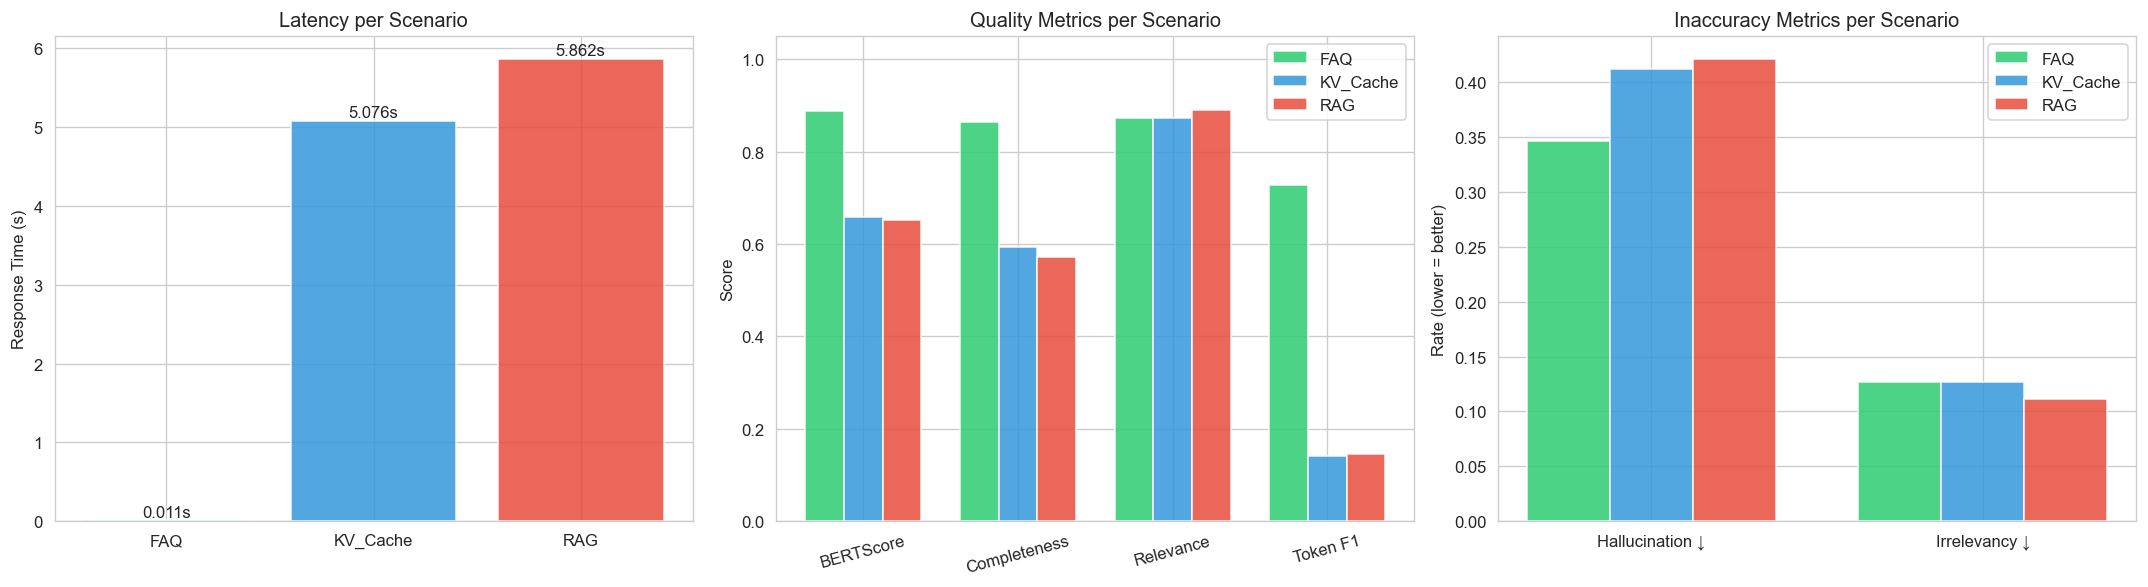

📁 Saved: logs/per_scenario_comparison.png


In [14]:
# 📊 Per-Scenario Visualization: FAQ vs KV_Cache vs RAG

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scenarios_available = [s for s in ['FAQ', 'KV_Cache', 'RAG'] if s in scenario_metrics]
colors = {'FAQ': '#2ecc71', 'KV_Cache': '#3498db', 'RAG': '#e74c3c'}

# --- 1. Latency comparison ---
ax = axes[0]
times = [scenario_metrics[s]['time_avg'] for s in scenarios_available]
bars = ax.bar(scenarios_available, times, color=[colors[s] for s in scenarios_available], alpha=0.85)
ax.set_ylabel('Response Time (s)')
ax.set_title('Latency per Scenario')
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}s', ha='center', va='bottom', fontsize=10)

# --- 2. Quality metrics comparison ---
ax = axes[1]
quality_metrics = ['bert', 'comp', 'rel', 'token_f1']
quality_labels  = ['BERTScore', 'Completeness', 'Relevance', 'Token F1']
x = np.arange(len(quality_metrics))
width = 0.25

for idx, sc in enumerate(scenarios_available):
    vals = [scenario_metrics[sc][m] for m in quality_metrics]
    ax.bar(x + idx * width, vals, width, label=sc, color=colors[sc], alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('Quality Metrics per Scenario')
ax.set_xticks(x + width * (len(scenarios_available) - 1) / 2)
ax.set_xticklabels(quality_labels, rotation=15)
ax.legend()
ax.set_ylim(0, 1.05)

# --- 3. Inaccuracy metrics comparison ---
ax = axes[2]
inacc_metrics = ['hall', 'irr']
inacc_labels  = ['Hallucination ↓', 'Irrelevancy ↓']
x = np.arange(len(inacc_metrics))

for idx, sc in enumerate(scenarios_available):
    vals = [scenario_metrics[sc][m] for m in inacc_metrics]
    ax.bar(x + idx * width, vals, width, label=sc, color=colors[sc], alpha=0.85)

ax.set_ylabel('Rate (lower = better)')
ax.set_title('Inaccuracy Metrics per Scenario')
ax.set_xticks(x + width * (len(scenarios_available) - 1) / 2)
ax.set_xticklabels(inacc_labels)
ax.legend()

plt.tight_layout()
plt.savefig('../logs/per_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: logs/per_scenario_comparison.png")

## KV-Cache Speedup Analysis

| Call | Path | Expected |
|------|------|----------|
| 1st | RAG retrieval → store to KV-Cache | Slower (cold) |
| 2nd | KV-Cache hit → return cached | Faster (warm) |

KV-Cache Speedup Analysis  (53 queries)
-----------------------------------------------------------------
  Outlier threshold (Q3+1.5×IQR): 1319.34x
  Outliers detected              : 3/53

  ── All queries ──────────────────────────────────────────
     Avg 1st call (RAG)    : 10.602s
     Avg 2nd call (KV$)    : 5.076s
     Median speedup        : 1.15x  ← primary metric
     Mean speedup          : 343.90x
     Max speedup           : 3726.31x

  ── Excluding 3 outlier(s) ────────────────────────────
     Avg 1st call (RAG)    : 10.937s
     Avg 2nd call (KV$)    : 5.381s
     Median speedup        : 1.12x
     Mean speedup (robust) : 210.67x
     Max speedup (robust)  : 1193.52x
-----------------------------------------------------------------

  #    Query                                                   1st(s)  2nd(s)   Speedup  KV-hit  Outlier
  ----------------------------------------------------------------------------------------------------
  1    Apakah ada penginapan mura

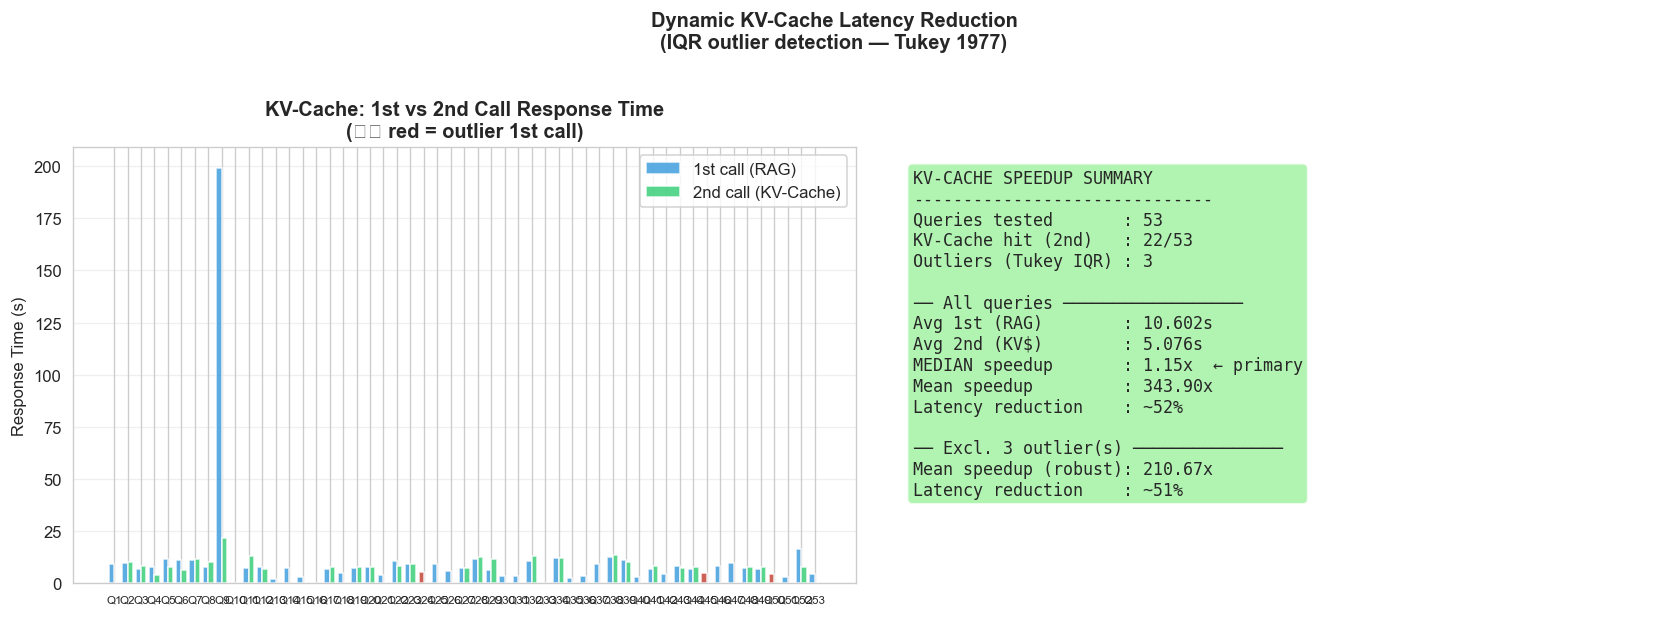

Saved: logs/kvcache_speedup.png

FAQ Static Cache Summary:
  Queries from FAQ cache : 147
  Avg response time      : 0.012s
  Speedup vs RAG avg     : 508.17x


In [15]:
# KV-Cache Speedup Analysis  (IQR-based outlier detection)
#
# Menggunakan median sebagai primary metric (lebih robust terhadap outlier).
# Outlier dideteksi via metode Tukey (1977): Q3 + 1.5 × IQR.
# Statistik dilaporkan dua cara: "all queries" dan "excluding outliers".

kvc_data = scenario_results.get('KV_Cache', [])

if not kvc_data:
    print("No KV_Cache data. All queries were served from the static FAQ cache.")
else:
    first_times  = [d['first_time']  for d in kvc_data]
    second_times = [d['second_time'] for d in kvc_data]
    speedups     = [d['speedup']     for d in kvc_data]

    # ── IQR Outlier Detection (Tukey 1977) ──────────────────────────────
    _sp_arr = np.array(speedups)
    _q1, _q3 = np.percentile(_sp_arr, 25), np.percentile(_sp_arr, 75)
    _iqr      = _q3 - _q1
    _upper    = _q3 + 1.5 * _iqr
    _outlier_mask = _sp_arr > _upper  # True = outlier

    speedups_clean   = _sp_arr[~_outlier_mask].tolist()
    ft_clean         = [ft for ft, out in zip(first_times,  _outlier_mask) if not out]
    st_clean         = [st for st, out in zip(second_times, _outlier_mask) if not out]
    n_outliers       = int(_outlier_mask.sum())

    print(f"KV-Cache Speedup Analysis  ({len(kvc_data)} queries)")
    print("-" * 65)
    print(f"  Outlier threshold (Q3+1.5×IQR): {_upper:.2f}x")
    print(f"  Outliers detected              : {n_outliers}/{len(kvc_data)}")
    print()
    print(f"  ── All queries ──────────────────────────────────────────")
    print(f"     Avg 1st call (RAG)    : {np.mean(first_times):.3f}s")
    print(f"     Avg 2nd call (KV$)    : {np.mean(second_times):.3f}s")
    print(f"     Median speedup        : {np.median(speedups):.2f}x  ← primary metric")
    print(f"     Mean speedup          : {np.mean(speedups):.2f}x")
    print(f"     Max speedup           : {max(speedups):.2f}x")
    if n_outliers > 0 and speedups_clean:
        print()
        print(f"  ── Excluding {n_outliers} outlier(s) ────────────────────────────")
        print(f"     Avg 1st call (RAG)    : {np.mean(ft_clean):.3f}s")
        print(f"     Avg 2nd call (KV$)    : {np.mean(st_clean):.3f}s")
        print(f"     Median speedup        : {np.median(speedups_clean):.2f}x")
        print(f"     Mean speedup (robust) : {np.mean(speedups_clean):.2f}x")
        print(f"     Max speedup (robust)  : {max(speedups_clean):.2f}x")
    print("-" * 65)

    print(f"\n  {'#':<4} {'Query':<54} {'1st(s)':>7} {'2nd(s)':>7} {'Speedup':>9} {'KV-hit':>7} {'Outlier':>8}")
    print("  " + "-" * 100)
    for j, d in enumerate(kvc_data, 1):
        q   = d['query'][:52] + ".." if len(d['query']) > 52 else d['query']
        hit = "YES" if d.get('cache_hit_2nd') else "NO"
        flag = " ⚠️" if _outlier_mask[j-1] else ""
        print(f"  {j:<4} {q:<54} {d['first_time']:>7.3f} {d['second_time']:>7.3f} "
              f"{d['speedup']:>8.2f}x {hit:>7}{flag}")

    # ── Plot ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Bar chart — 1st vs 2nd call; outliers shown with hatching
    ax = axes[0]
    x   = np.arange(len(kvc_data))
    bar_colors_ft = ['#c0392b' if out else '#3498db' for out in _outlier_mask]
    bar_colors_st = ['#c0392b' if out else '#2ecc71' for out in _outlier_mask]
    ax.bar(x - 0.2, first_times,  0.4, label='1st call (RAG)',      color=bar_colors_ft, alpha=0.8)
    ax.bar(x + 0.2, second_times, 0.4, label='2nd call (KV-Cache)', color=bar_colors_st, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Q{j+1}" for j in range(len(kvc_data))], fontsize=7)
    ax.set_ylabel('Response Time (s)')
    ax.set_title('KV-Cache: 1st vs 2nd Call Response Time\n(⚠️ red = outlier 1st call)', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Right: Summary text box
    ax = axes[1]
    ax.axis('off')
    hit_count = sum(1 for d in kvc_data if d.get('cache_hit_2nd'))
    reduction_all   = (1 - np.mean(second_times) / np.mean(first_times)) * 100 if np.mean(first_times) > 0 else 0
    reduction_clean = (1 - np.mean(st_clean) / np.mean(ft_clean)) * 100 if (ft_clean and np.mean(ft_clean) > 0) else 0
    summary_txt = (
        "KV-CACHE SPEEDUP SUMMARY\n"
        + "-" * 30 + "\n"
        + f"Queries tested       : {len(kvc_data)}\n"
        + f"KV-Cache hit (2nd)   : {hit_count}/{len(kvc_data)}\n"
        + f"Outliers (Tukey IQR) : {n_outliers}\n\n"
        + f"── All queries ──────────────────\n"
        + f"Avg 1st (RAG)        : {np.mean(first_times):.3f}s\n"
        + f"Avg 2nd (KV$)        : {np.mean(second_times):.3f}s\n"
        + f"MEDIAN speedup       : {np.median(speedups):.2f}x  ← primary\n"
        + f"Mean speedup         : {np.mean(speedups):.2f}x\n"
        + f"Latency reduction    : ~{reduction_all:.0f}%\n"
    )
    if n_outliers > 0 and speedups_clean:
        summary_txt += (
            f"\n── Excl. {n_outliers} outlier(s) ───────────────\n"
            + f"Mean speedup (robust): {np.mean(speedups_clean):.2f}x\n"
            + f"Latency reduction    : ~{reduction_clean:.0f}%"
        )
    ax.text(0.05, 0.95, summary_txt, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

    plt.suptitle('Dynamic KV-Cache Latency Reduction\n(IQR outlier detection — Tukey 1977)',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../logs/kvcache_speedup.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: logs/kvcache_speedup.png")


# FAQ static cache summary
faq_data = scenario_results.get('FAQ', [])
if faq_data:
    a_times = [r['time'] for r in faq_data]
    rag_avg = rag_m['time_avg']
    print(f"\nFAQ Static Cache Summary:")
    print(f"  Queries from FAQ cache : {len(faq_data)}")
    print(f"  Avg response time      : {np.mean(a_times):.3f}s")
    if rag_avg > 0:
        print(f"  Speedup vs RAG avg     : {rag_avg / np.mean(a_times):.2f}x")


## Latency Analysis
Per-query response time, cache hit vs miss, distribusi latency.

📈 3-TIER SPEEDUP BREAKDOWN
   Ref: Guo et al. (2022) Prompt Cache; Zhu et al. (2023) RAGCache
  Tier 1 — FAQ Static Cache
    Queries          : 147
    Avg FAQ time     : 0.012s
    Avg RAG time     : 5.862s
    Speedup          : 508.17x

  Tier 2 — KV-Cache Warm Hit
    Pairs tested     : 53
    Avg 1st (miss)   : 10.602s
    Avg 2nd (hit)    : 5.076s
    Speedup          : 343.90x
    Min / Max        : 0.00x / 3726.31x

  Tier 3 — Overall (CAG vs RAG)
    Avg RAG time     : 5.862s
    Avg CAG time     : 1.354s
    Speedup          : 4.33x
    Cache Hit Rate   : 84.5%


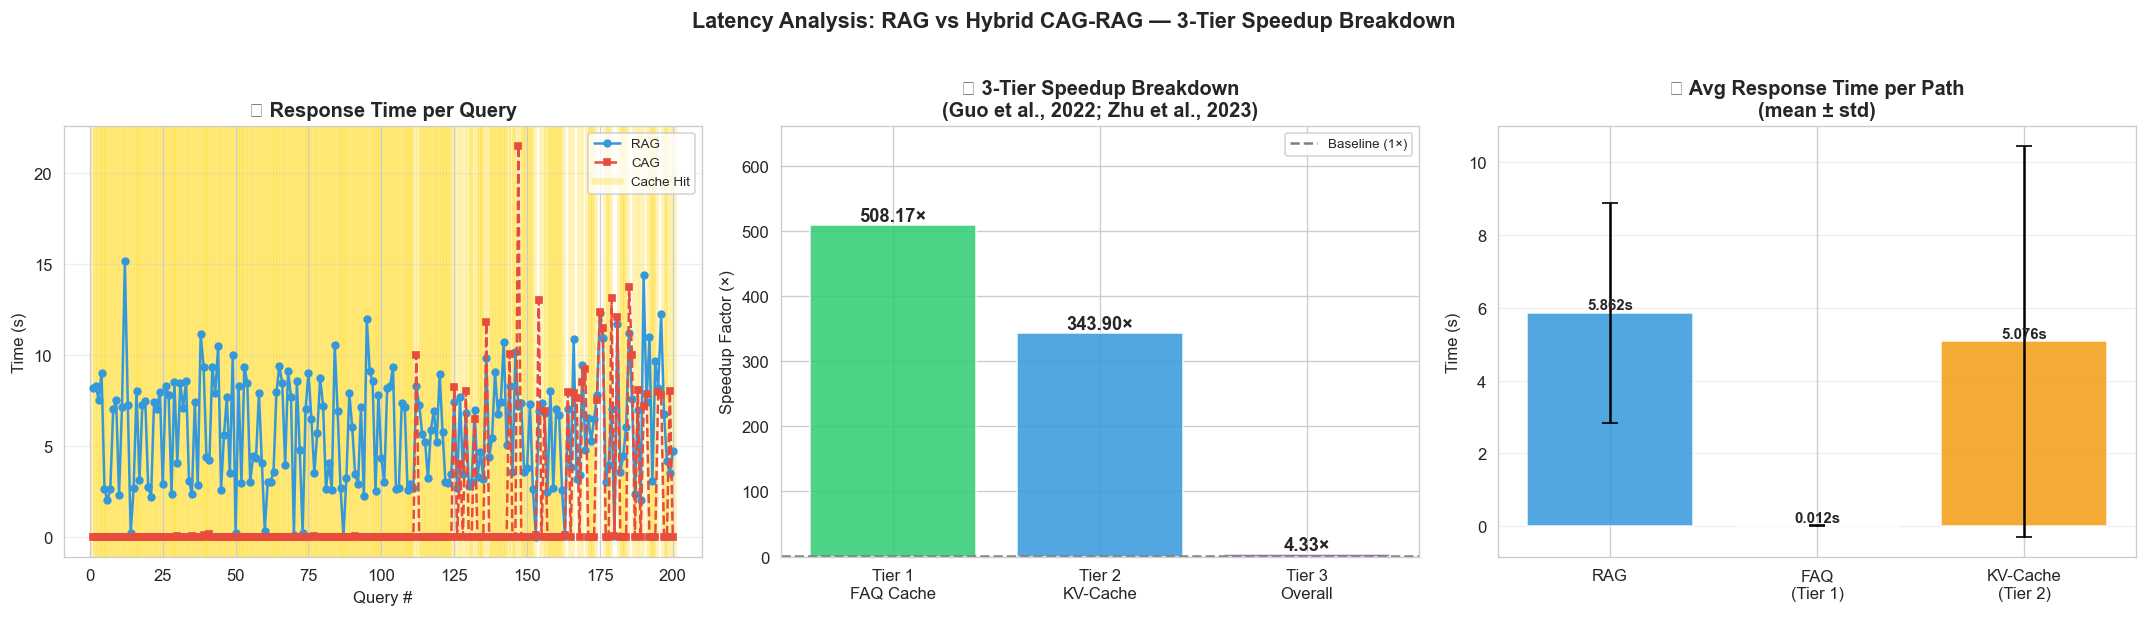

✅ Saved: logs/latency_analysis.png


In [16]:
# 📈 LATENCY ANALYSIS — 3-Tier Speedup Breakdown
#
# Tier 1 — FAQ Static Cache  : RAG_avg / FAQ_avg
#           Pertanyaan dari FAQ static cache vs pure retrieval.
# Tier 2 — KV-Cache Warm Hit : avg(first_time / second_time) per query
#           1st call = RAG miss+store, 2nd call = warm cache hit.
# Tier 3 — Overall           : RAG_avg / CAG_avg (gabungan kedua jalur)
#
# Ref: Guo et al. (2022) "Prompt Cache: Modular Attention Reuse for LLMs"
#      Zhu et al.  (2023) "RAGCache: Efficient Knowledge Caching for Retrieval"

rag_times  = rag_m['_time']
cag_times  = cag_m['_time'] if cag_m else []
cag_hit_t  = [r['time'] for r in cag_res if r.get('cache')]
cag_miss_t = [r['time'] for r in cag_res if not r.get('cache')]

# ── Hitung 3 tier speedup ─────────────────────────────────────────────────
faq_entries = scenario_results.get('FAQ', [])
kvc_entries = scenario_results.get('KV_Cache', [])

tier1_faq_times = [r['time'] for r in faq_entries]
tier2_kvc_spdup = [d['speedup'] for d in kvc_entries if 'speedup' in d]

tier1_speedup = (rag_m['time_avg'] / np.mean(tier1_faq_times)) if tier1_faq_times else None
tier2_speedup = np.mean(tier2_kvc_spdup) if tier2_kvc_spdup else None
tier3_speedup = speedup if cag_m else None

print("=" * 62)
print("📈 3-TIER SPEEDUP BREAKDOWN")
print("   Ref: Guo et al. (2022) Prompt Cache; Zhu et al. (2023) RAGCache")
print("=" * 62)
print(f"  Tier 1 — FAQ Static Cache")
print(f"    Queries          : {len(tier1_faq_times)}")
if tier1_faq_times:
    print(f"    Avg FAQ time     : {np.mean(tier1_faq_times):.3f}s")
    print(f"    Avg RAG time     : {rag_m['time_avg']:.3f}s")
    print(f"    Speedup          : {tier1_speedup:.2f}x")

print(f"\n  Tier 2 — KV-Cache Warm Hit")
print(f"    Pairs tested     : {len(tier2_kvc_spdup)}")
if tier2_kvc_spdup:
    print(f"    Avg 1st (miss)   : {np.mean([d['first_time'] for d in kvc_entries]):.3f}s")
    print(f"    Avg 2nd (hit)    : {np.mean([d['second_time'] for d in kvc_entries]):.3f}s")
    print(f"    Speedup          : {tier2_speedup:.2f}x")
    print(f"    Min / Max        : {min(tier2_kvc_spdup):.2f}x / {max(tier2_kvc_spdup):.2f}x")

print(f"\n  Tier 3 — Overall (CAG vs RAG)")
if cag_m:
    print(f"    Avg RAG time     : {rag_m['time_avg']:.3f}s")
    print(f"    Avg CAG time     : {cag_m['time_avg']:.3f}s")
    print(f"    Speedup          : {tier3_speedup:.2f}x")
    print(f"    Cache Hit Rate   : {cag_m['chr']:.1f}%")
print("=" * 62)

# ── Visualisasi 3-panel ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Per-query Response Time (line plot) -----
ax = axes[0]
queries_idx = list(range(1, len(rag_times) + 1))
ax.plot(queries_idx, rag_times, 'o-', color='#3498db', label='RAG',
        linewidth=1.5, markersize=4)
if cag_times:
    ax.plot(queries_idx[:len(cag_times)], cag_times, 's--', color='#e74c3c',
            label='CAG', linewidth=1.5, markersize=4)
    for i, r in enumerate(cag_res):
        if r.get('cache'):
            ax.axvline(x=i+1, color='gold', alpha=0.3, linewidth=4, zorder=0,
                       label=('Cache Hit' if i == 0 else ''))
ax.set_title('⚡ Response Time per Query', fontweight='bold')
ax.set_xlabel('Query #'); ax.set_ylabel('Time (s)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# --- 2. 3-Tier Speedup Bar Chart (Guo et al., 2022; Zhu et al., 2023) -----
ax = axes[1]
tier_labels, tier_vals, tier_colors = [], [], []
if tier1_speedup is not None:
    tier_labels.append('Tier 1\nFAQ Cache');    tier_vals.append(tier1_speedup); tier_colors.append('#2ecc71')
if tier2_speedup is not None:
    tier_labels.append('Tier 2\nKV-Cache');     tier_vals.append(tier2_speedup); tier_colors.append('#3498db')
if tier3_speedup is not None:
    tier_labels.append('Tier 3\nOverall');      tier_vals.append(tier3_speedup); tier_colors.append('#9b59b6')

if tier_vals:
    bars = ax.bar(tier_labels, tier_vals, color=tier_colors, alpha=0.85, edgecolor='white')
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, label='Baseline (1×)')
    for bar, val in zip(bars, tier_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}×', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_ylabel('Speedup Factor (×)')
    ax.set_title('🚀 3-Tier Speedup Breakdown\n(Guo et al., 2022; Zhu et al., 2023)',
                 fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(tier_vals) * 1.3 if tier_vals else 2)

# --- 3. Avg response time per path (bar) -----
ax = axes[2]
sys_names, means, stds, bar_colors = ['RAG'], [rag_m['time_avg']], [rag_m['time_std']], ['#3498db']

if tier1_faq_times:
    sys_names.append('FAQ\n(Tier 1)');  means.append(round(float(np.mean(tier1_faq_times)), 3))
    stds.append(round(float(np.std(tier1_faq_times, ddof=1)), 3) if len(tier1_faq_times) > 1 else 0)
    bar_colors.append('#2ecc71')

if kvc_entries:
    t2 = [d['second_time'] for d in kvc_entries]
    sys_names.append('KV-Cache\n(Tier 2)'); means.append(round(float(np.mean(t2)), 3))
    stds.append(round(float(np.std(t2, ddof=1)), 3) if len(t2) > 1 else 0)
    bar_colors.append('#f39c12')

bars = ax.bar(sys_names, means, color=bar_colors,
              yerr=[s if s > 0 else None for s in stds],
              capsize=5, edgecolor='white', alpha=0.85)
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f'{v:.3f}s', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_title('📊 Avg Response Time per Path\n(mean ± std)', fontweight='bold')
ax.set_ylabel('Time (s)'); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Latency Analysis: RAG vs Hybrid CAG-RAG — 3-Tier Speedup Breakdown',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../logs', exist_ok=True)
plt.savefig('../logs/latency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/latency_analysis.png")


## Quality & Inaccuracy Visualization

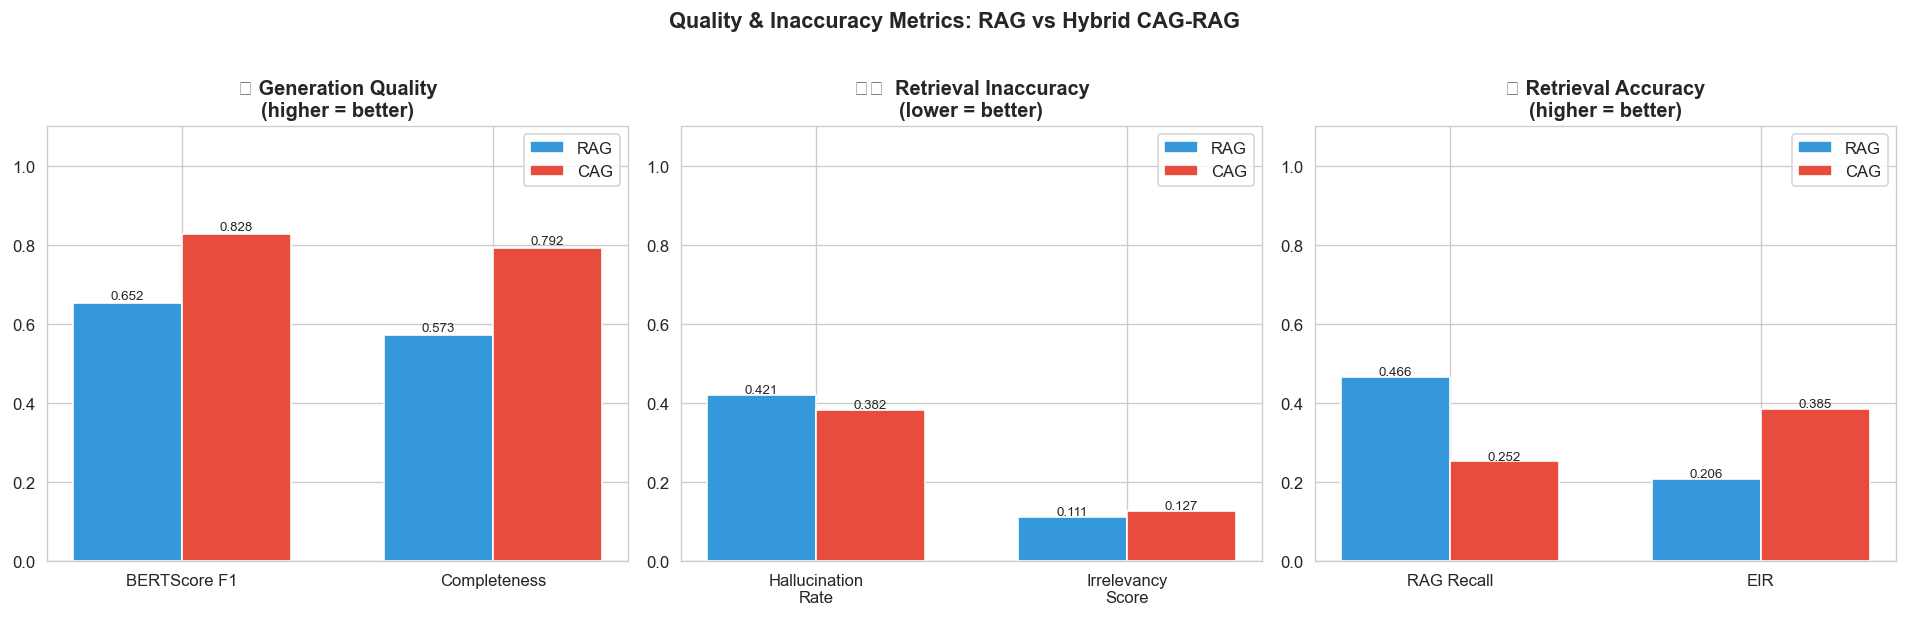

✅ Saved: logs/quality_metrics.png


In [17]:
# 📊 QUALITY & INACCURACY VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sys_names = ['RAG'] + (['CAG'] if cag_m else [])
colors    = ['#3498db', '#e74c3c']

# --- 1. Generation Quality (BERTScore & Completeness) -----
ax = axes[0]
metrics_q   = ['BERTScore F1', 'Completeness']
rag_q_vals  = [rag_m['bert'], rag_m['comp']]
x = np.arange(len(metrics_q)); w = 0.35
ax.bar(x - w/2, rag_q_vals, w, label='RAG', color='#3498db')
if cag_m:
    cag_q_vals = [cag_m['bert'], cag_m['comp']]
    ax.bar(x + w/2, cag_q_vals, w, label='CAG', color='#e74c3c')
    for i, (rv, cv) in enumerate(zip(rag_q_vals, cag_q_vals)):
        ax.text(i - w/2, rv + .01, f'{rv:.3f}', ha='center', fontsize=8)
        ax.text(i + w/2, cv + .01, f'{cv:.3f}', ha='center', fontsize=8)
else:
    for i, rv in enumerate(rag_q_vals):
        ax.text(i, rv + .01, f'{rv:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics_q)
ax.set_title('🎯 Generation Quality\n(higher = better)', fontweight='bold')
ax.set_ylim(0, 1.1); ax.legend()

# --- 2. Retrieval Inaccuracy (lower = better) -----
ax = axes[1]
metrics_i  = ['Hallucination\nRate', 'Irrelevancy\nScore']
rag_i_vals = [rag_m['hall'], rag_m['irr']]
x = np.arange(len(metrics_i))
ax.bar(x - w/2, rag_i_vals, w, label='RAG', color='#3498db')
if cag_m:
    cag_i_vals = [cag_m['hall'], cag_m['irr']]
    ax.bar(x + w/2, cag_i_vals, w, label='CAG', color='#e74c3c')
    for i, (rv, cv) in enumerate(zip(rag_i_vals, cag_i_vals)):
        ax.text(i - w/2, rv + .005, f'{rv:.3f}', ha='center', fontsize=8)
        ax.text(i + w/2, cv + .005, f'{cv:.3f}', ha='center', fontsize=8)
else:
    for i, rv in enumerate(rag_i_vals):
        ax.text(i, rv + .005, f'{rv:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics_i)
ax.set_title('⚠️  Retrieval Inaccuracy\n(lower = better)', fontweight='bold')
ax.set_ylim(0, 1.1); ax.legend()

# --- 3. Retrieval Accuracy (RAG Recall & EIR) -----
ax = axes[2]
metrics_r  = ['RAG Recall', 'EIR']
rag_r_vals = [rag_m['recall'], rag_m['eir']]
x = np.arange(len(metrics_r))
ax.bar(x - w/2, rag_r_vals, w, label='RAG', color='#3498db')
if cag_m:
    cag_r_vals = [cag_m['recall'], cag_m['eir']]
    ax.bar(x + w/2, cag_r_vals, w, label='CAG', color='#e74c3c')
    for i, (rv, cv) in enumerate(zip(rag_r_vals, cag_r_vals)):
        ax.text(i - w/2, rv + .005, f'{rv:.3f}', ha='center', fontsize=8)
        ax.text(i + w/2, cv + .005, f'{cv:.3f}', ha='center', fontsize=8)
else:
    for i, rv in enumerate(rag_r_vals):
        ax.text(i, rv + .005, f'{rv:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics_r)
ax.set_title('🔍 Retrieval Accuracy\n(higher = better)', fontweight='bold')
ax.set_ylim(0, 1.1); ax.legend()

plt.suptitle('Quality & Inaccuracy Metrics: RAG vs Hybrid CAG-RAG',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../logs/quality_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/quality_metrics.png")

## Score Distribution — Box Plot (Tukey 1977; Rajpurkar et al. 2016)
Distribusi per-query score per skenario divisualisasikan sebagai box plot.
Ref: Tukey (1977) *Exploratory Data Analysis*; Rajpurkar et al. (2016) SQuAD §4; Wilke (2019) *Fundamentals of Data Visualization*.

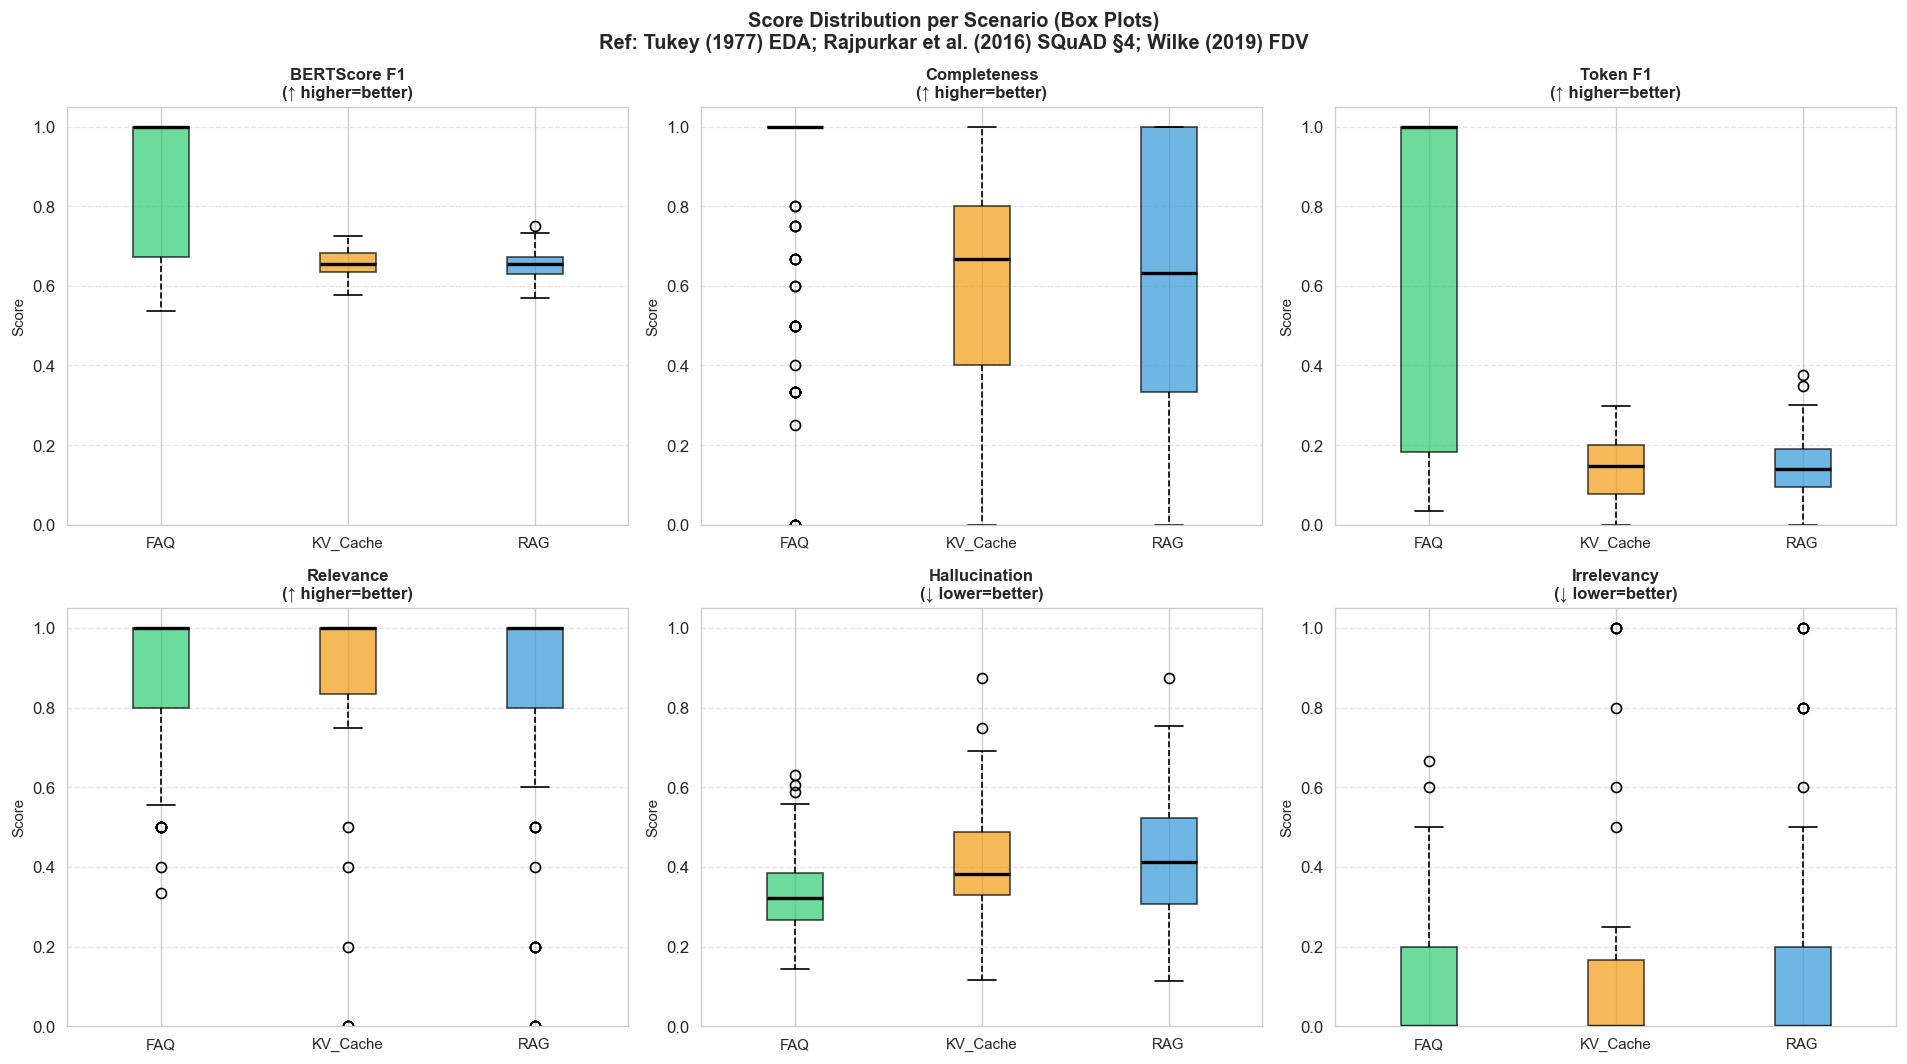

✅ Saved: logs/boxplot_distribution.png


In [18]:
# 📦 SCORE DISTRIBUTION — BOX PLOTS
#
# Justifikasi:
#   Box plot menampilkan median, IQR, dan outlier secara eksplisit
#   (Tukey 1977, Exploratory Data Analysis).
#   Rajpurkar et al. (2016) SQuAD §4 menggunakan distribusi per-metric
#   untuk membandingkan antar-skenario secara statistik bermakna.
#   Wilke (2019) Fundamentals of Data Visualization: box plot lebih informatif
#   dari bar chart untuk data berdistribusi tidak simetris.
#
# Metric (higher-is-better kecuali Hallucination & Irrelevancy):

_box_metrics = [
    ('bert',   'BERTScore F1',  True),
    ('comp',   'Completeness',  True),
    ('tf1',    'Token F1',      True),
    ('rel',    'Relevance',     True),
    ('hall',   'Hallucination', False),   # lower = better
    ('irr',    'Irrelevancy',   False),   # lower = better
]

_scen_colors = {
    'FAQ':      '#2ecc71',
    'KV_Cache': '#f39c12',
    'RAG':      '#3498db',
    'CAG':      '#e74c3c',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    'Score Distribution per Scenario (Box Plots)\n'
    'Ref: Tukey (1977) EDA; Rajpurkar et al. (2016) SQuAD §4; Wilke (2019) FDV',
    fontsize=12, fontweight='bold'
)

for ax, (mkey, mlabel, higher_better) in zip(axes.flat, _box_metrics):
    data_series = []
    labels_bp   = []
    colors_bp   = []

    for scen, sres in scenario_results.items():
        vals_clean = [
            r.get('metrics', {}).get(mkey, float('nan'))
            for r in sres
        ]
        vals_clean = [v for v in vals_clean if v == v]  # drop NaN
        if vals_clean:
            data_series.append(vals_clean)
            labels_bp.append(scen)
            colors_bp.append(_scen_colors.get(scen, '#95a5a6'))

    if not data_series:
        ax.set_visible(False)
        continue

    bp = ax.boxplot(
        data_series, patch_artist=True, notch=False,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linestyle='--'),
    )
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticklabels(labels_bp, fontsize=9)
    direction = '↑ higher=better' if higher_better else '↓ lower=better'
    ax.set_title(f'{mlabel}\n({direction})', fontsize=10, fontweight='bold')
    ax.set_ylabel('Score', fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../logs/boxplot_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/boxplot_distribution.png")

## Per-Query Metric Heatmap (Petroni et al. 2019)
Visualisasi konsistensi kinerja per-query di berbagai metrik dan skenario.
Ref: Petroni et al. (2019) *Language Models as Knowledge Bases* (LAMA) — inter-metric heatmap.

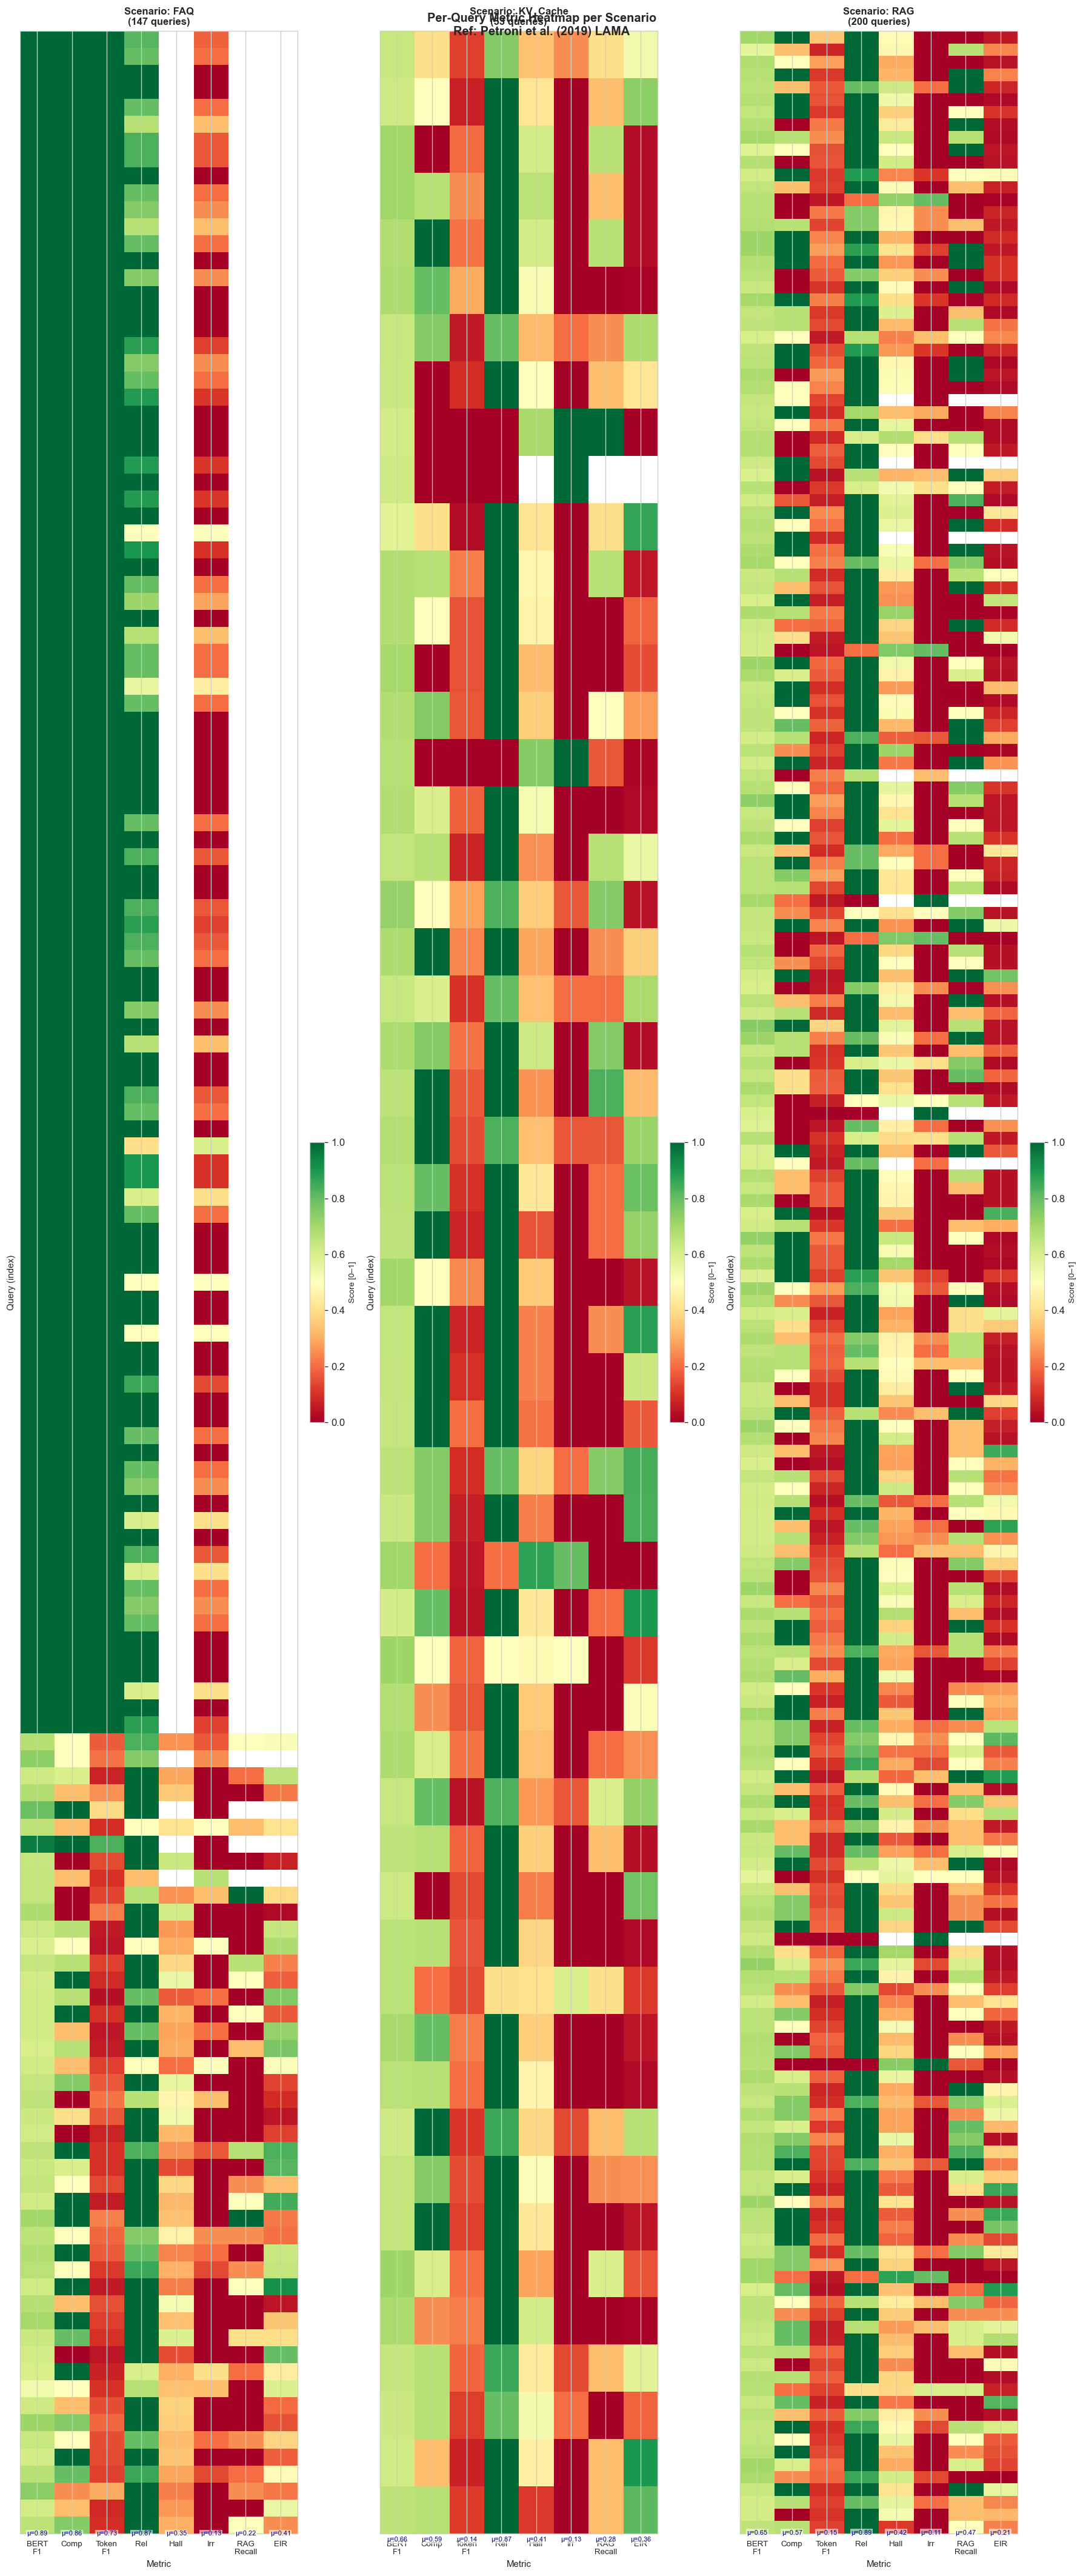

✅ Saved: logs/heatmap_perquery.png


In [19]:
# 🗺️  PER-QUERY METRIC HEATMAP
#
# Justifikasi:
#   Petroni et al. (2019) LAMA menggunakan heatmap untuk memvisualisasikan
#   konsistensi kinerja per-query di berbagai skenario sekaligus.
#   Heatmap membantu mengidentifikasi outlier dan query yang secara konsisten
#   berkinerja buruk, yang tidak terlihat pada ringkasan rata-rata saja.

import numpy as _np_hm

_hm_keys   = ['bert', 'comp', 'tf1', 'rel', 'hall', 'irr', 'recall', 'eir']
_hm_labels = ['BERT\nF1', 'Comp', 'Token\nF1', 'Rel', 'Hall', 'Irr', 'RAG\nRecall', 'EIR']

_scen_order = [s for s in ['FAQ', 'KV_Cache', 'RAG', 'CAG'] if s in scenario_results]

if not _scen_order:
    print("⚠️  Tidak ada data skenario — jalankan sel evaluasi terlebih dahulu")
else:
    n_scen = len(_scen_order)
    fig, axes = plt.subplots(1, n_scen, figsize=(5 * n_scen, max(6, len(scenario_results.get(_scen_order[0], [])) // 4)),
                             squeeze=False)
    fig.suptitle(
        'Per-Query Metric Heatmap per Scenario\n'
        'Ref: Petroni et al. (2019) LAMA',
        fontsize=12, fontweight='bold'
    )

    for col, scen in enumerate(_scen_order):
        sres = scenario_results[scen]
        n_q  = len(sres)
        mat  = _np_hm.full((n_q, len(_hm_keys)), _np_hm.nan)

        for row, r in enumerate(sres):
            for c, mk in enumerate(_hm_keys):
                v = r.get('metrics', {}).get(mk, _np_hm.nan)
                if v == v:  # not NaN
                    mat[row, c] = v

        ax = axes[0][col]
        im = ax.imshow(mat, aspect='auto', vmin=0, vmax=1,
                       cmap='RdYlGn', interpolation='nearest')

        ax.set_xticks(range(len(_hm_labels)))
        ax.set_xticklabels(_hm_labels, fontsize=8)
        ax.set_yticks([])
        ax.set_xlabel('Metric', fontsize=9)
        ax.set_ylabel('Query (index)', fontsize=9)
        ax.set_title(f'Scenario: {scen}\n({n_q} queries)', fontsize=10, fontweight='bold')

        # Colorbar
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label('Score [0–1]', fontsize=8)

        # Mean annotation row below heatmap
        for c in range(len(_hm_keys)):
            col_vals = [mat[r, c] for r in range(n_q) if not _np_hm.isnan(mat[r, c])]
            if col_vals:
                ax.text(c, n_q - 0.3, f'μ={_np_hm.mean(col_vals):.2f}',
                        ha='center', va='bottom', fontsize=6.5, color='navy',
                        bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none'))

    plt.tight_layout()
    plt.savefig('../logs/heatmap_perquery.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: logs/heatmap_perquery.png")

## Statistical Significance Testing
Paired t-test (p < 0.05) + Cohen's d effect size.

🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test, NaN-aware)
   H0: No difference between RAG and Hybrid CAG-RAG
   H1: Significant difference exists (p < 0.05)
   NaN positions (FAQ path) are excluded from all tests.

  Metric                     N   RAG µ   CAG µ   t-stat   p-value       d  Result
  ----------------------------------------------------------------------------------
  Response Time            200  5.8623  1.3537   16.577    0.0000   1.172  ✅ H1 supported
  BERTScore F1             200  0.6523  0.8276  -13.949    0.0000  -0.986  ✅ H1 supported
  Completeness             200  0.5725  0.7923   -8.024    0.0000  -0.567  ✅ H1 supported
  Hallucination Rate       95*  0.4210  0.3823    0.887    0.3772   0.091  ❌ not significant
  Irrelevancy Score        200  0.1111  0.1269   -1.036    0.3013  -0.073  ❌ not significant
  RAG Recall               95*  0.4660  0.2516    7.370    0.0000   0.756  ⚠️  sig. but reversed
  EIR                      95*  0.2061  0.3854   -3.604    0.0

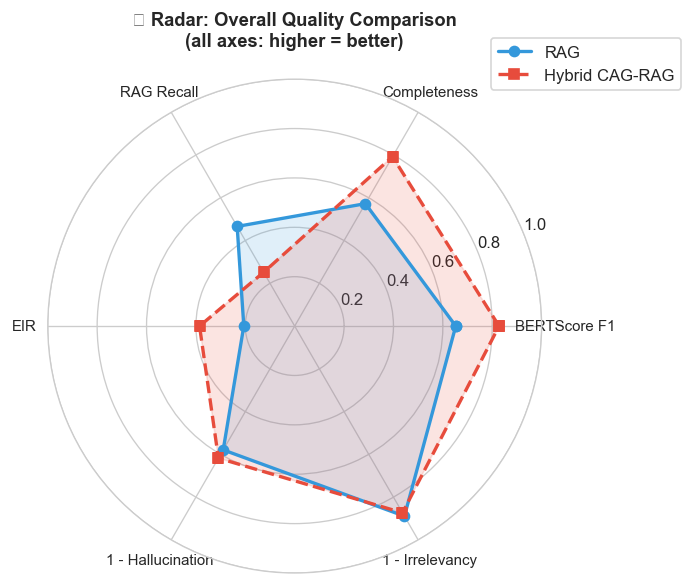

✅ Saved: logs/radar_comparison.png


In [20]:
# 🔬 STATISTICAL SIGNIFICANCE TESTING  (Paired t-test + Cohen's d)
if not cag_m:
    print("⚠️  CAG results not available, skipping statistical tests.")
else:
    print("=" * 72)
    print("🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test, NaN-aware)")
    print("   H0: No difference between RAG and Hybrid CAG-RAG")
    print("   H1: Significant difference exists (p < 0.05)")
    print("   NaN positions (FAQ path) are excluded from all tests.")
    print("=" * 72)

    # Metrik yang diuji — arah = 'lower' → CAG harus lebih rendah, 'higher' → CAG harus lebih tinggi
    test_metrics = [
        # (label,              rag_list,           cag_list,           better_direction)
        ("Response Time",      rag_m['_time'],     cag_m['_time'],     "lower"),
        ("BERTScore F1",       rag_m['_bert'],     cag_m['_bert'],     "higher"),
        ("Completeness",       rag_m['_comp'],     cag_m['_comp'],     "higher"),
        ("Hallucination Rate", rag_m['_hall'],     cag_m['_hall'],     "lower"),
        ("Irrelevancy Score",  rag_m['_irr'],      cag_m['_irr'],      "lower"),
        ("RAG Recall",         rag_m['_recall'],   cag_m['_recall'],   "higher"),
        ("EIR",                rag_m['_eir'],      cag_m['_eir'],      "higher"),
    ]

    stat_rows = []
    print(f"\n  {'Metric':<22} {'N':>5} {'RAG µ':>7} {'CAG µ':>7} {'t-stat':>8} {'p-value':>9} {'d':>7}  Result")
    print("  " + "-" * 82)

    for lbl, rag_vals, cag_vals, direction in test_metrics:
        if len(rag_vals) < 2 or len(cag_vals) < 2:
            print(f"  {lbl:<22}  (insufficient data — need ≥ 2 queries)")
            continue

        t_stat, p_val, n_valid = paired_ttest(rag_vals, cag_vals)
        d                      = cohens_d(rag_vals, cag_vals)

        if n_valid < 2:
            print(f"  {lbl:<22}  (no valid pairs after NaN removal — skipped)")
            continue

        # Means computed only on non-NaN values for fair representation
        rag_clean = [x for x in rag_vals if not (isinstance(x, float) and np.isnan(x))]
        cag_clean = [x for x in cag_vals if not (isinstance(x, float) and np.isnan(x))]
        rag_mu    = round(float(np.mean(rag_clean)), 4) if rag_clean else float('nan')
        cag_mu    = round(float(np.mean(cag_clean)), 4) if cag_clean else float('nan')

        significant = not np.isnan(p_val) and p_val < 0.05

        # Check if direction is as expected
        if direction == "lower":
            direction_ok = cag_mu <= rag_mu
        else:
            direction_ok = cag_mu >= rag_mu

        if significant and direction_ok:
            result = "✅ H1 supported"
        elif significant and not direction_ok:
            result = "⚠️  sig. but reversed"
        else:
            result = "❌ not significant"

        n_str = f"{n_valid}" if n_valid == len(rag_vals) else f"{n_valid}*"
        print(f"  {lbl:<22} {n_str:>5} {rag_mu:>7.4f} {cag_mu:>7.4f} "
              f"{t_stat:>8.3f} {p_val:>9.4f} {d:>7.3f}  {result}")
        stat_rows.append({
            'Metric': lbl, 'N': n_valid, 'RAG_mean': rag_mu, 'CAG_mean': cag_mu,
            't_stat': t_stat, 'p_value': p_val, "Cohen_d": d,
            'significant': significant, 'direction_ok': direction_ok
        })

    print("\n  * N < total = beberapa posisi NaN (FAQ path) dikecualikan")
    print("  Legend: ✅ Hypothesis supported  |  ❌ Not significant  |  ⚠️  Unexpected direction")
    print(f"  α = 0.05  |  Effect size: small < 0.2,  medium 0.2–0.8,  large > 0.8")

    # Radar chart for visual comparison
    stat_df = pd.DataFrame(stat_rows)

    # Radar chart
    radar_metrics = ['BERTScore F1', 'Completeness', 'RAG Recall', 'EIR']
    rag_radar  = [rag_m['bert'], rag_m['comp'], rag_m['recall'], rag_m['eir']]
    cag_radar  = [cag_m['bert'], cag_m['comp'], cag_m['recall'], cag_m['eir']]

    # Invert inaccuracy metrics so higher = better on radar
    # Guard against NaN for hallucination (FAQ path excluded from mean already)
    rag_hall_val = rag_m['hall'] if not (isinstance(rag_m['hall'], float) and np.isnan(rag_m['hall'])) else 0.5
    cag_hall_val = cag_m['hall'] if not (isinstance(cag_m['hall'], float) and np.isnan(cag_m['hall'])) else 0.5

    radar_metrics += ['1 - Hallucination', '1 - Irrelevancy']
    rag_radar  += [1 - rag_hall_val, 1 - rag_m['irr']]
    cag_radar  += [1 - cag_hall_val, 1 - cag_m['irr']]

    # Replace any remaining NaN with 0 for radar chart rendering
    rag_radar = [v if not (isinstance(v, float) and np.isnan(v)) else 0.0 for v in rag_radar]
    cag_radar = [v if not (isinstance(v, float) and np.isnan(v)) else 0.0 for v in cag_radar]

    N   = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    rag_r  = rag_radar + [rag_radar[0]]
    cag_r  = cag_radar + [cag_radar[0]]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, rag_r, 'o-', color='#3498db', linewidth=2, label='RAG')
    ax.fill(angles, rag_r, alpha=0.15, color='#3498db')
    ax.plot(angles, cag_r, 's--', color='#e74c3c', linewidth=2, label='Hybrid CAG-RAG')
    ax.fill(angles, cag_r, alpha=0.15, color='#e74c3c')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title('📡 Radar: Overall Quality Comparison\n(all axes: higher = better)',
                 fontsize=11, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig('../logs/radar_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: logs/radar_comparison.png")


## Save & Export

In [21]:
# Save & Export All Results

import json
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
os.makedirs('../logs', exist_ok=True)

# 1. Summary metrics JSON
summary_export = {
    'timestamp':    ts,
    'dataset_size': len(dataset),
    'rag': {k: v for k, v in rag_m.items() if not k.startswith('_') and k != 'per_query'},
    'cag': ({k: v for k, v in cag_m.items() if not k.startswith('_') and k != 'per_query'}
            if cag_m else None),
    'speedup_factor': round(speedup, 4) if cag_m else None,
    'scenario_faq': {
        'total_hits': len(scenario_results.get('FAQ', [])),
        'avg_time':   (round(float(np.mean([r['time'] for r in scenario_results['FAQ']])), 3)
                       if scenario_results.get('FAQ') else None),
    },
    'scenario_kvcache': {
        'total_tested': len(scenario_results.get('KV_Cache', [])),
        'avg_speedup':  (round(float(np.mean([d['speedup']
                                               for d in scenario_results['KV_Cache']])), 3)
                         if scenario_results.get('KV_Cache') else None),
    },
}

json_path = f'../logs/eval_summary_{ts}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary_export, f, indent=2, ensure_ascii=False)
print(f"Summary JSON     : {json_path}")

# 2. Per-query CSV — RAG
if rag_m['per_query']:
    rag_csv = f'../logs/eval_rag_perquery_{ts}.csv'
    pd.DataFrame(rag_m['per_query']).to_csv(rag_csv, index=False)
    print(f"RAG per-query    : {rag_csv}")

# 3. Per-query CSV — CAG
if cag_m and cag_m['per_query']:
    cag_csv = f'../logs/eval_cag_perquery_{ts}.csv'
    pd.DataFrame(cag_m['per_query']).to_csv(cag_csv, index=False)
    print(f"CAG per-query    : {cag_csv}")

# 4. KV-Cache scenario CSV
if scenario_results.get('KV_Cache'):
    kvc_csv = f'../logs/eval_kvcache_{ts}.csv'
    pd.DataFrame(scenario_results['KV_Cache']).to_csv(kvc_csv, index=False)
    print(f"KV-Cache scenario: {kvc_csv}")

# 5. Statistical results CSV
if cag_m and 'stat_df' in dir():
    stat_csv = f'../logs/eval_stats_{ts}.csv'
    stat_df.to_csv(stat_csv, index=False)
    print(f"Statistics       : {stat_csv}")

# Key Findings
print("\n" + "=" * 65)
print("KEY FINDINGS  —  Hybrid CAG-RAG vs Pure RAG")
print("=" * 65)

print(f"\n  RQ1 LATENCY")
print(f"    RAG avg time   : {rag_m['time_avg']:.3f}s +/- {rag_m['time_std']:.3f}s")
if cag_m:
    print(f"    CAG avg time   : {cag_m['time_avg']:.3f}s +/- {cag_m['time_std']:.3f}s")
    print(f"    Speedup factor : {speedup:.2f}x  ({'OK' if speedup > 1 else 'NO IMPROVEMENT'})")
    print(f"    Cache Hit Rate : {cag_m['chr']:.1f}%")
    kvc = scenario_results.get('KV_Cache', [])
    if kvc:
        print(f"    KV-Cache speedup (avg): {np.mean([d['speedup'] for d in kvc]):.2f}x")

print(f"\n  RQ2 INACCURACY")
if cag_m:
    hall_d = rag_m['hall'] - cag_m['hall']
    irr_d  = rag_m['irr']  - cag_m['irr']
    rel_d  = cag_m['rel']  - rag_m['rel']
    print(f"    Hallucination  RAG={rag_m['hall']:.4f}  CAG={cag_m['hall']:.4f}  delta={hall_d:+.4f}")
    print(f"    Irrelevancy    RAG={rag_m['irr']:.4f}  CAG={cag_m['irr']:.4f}  delta={irr_d:+.4f}")
    print(f"    Relevance      RAG={rag_m['rel']:.4f}  CAG={cag_m['rel']:.4f}  delta={rel_d:+.4f}")

    print(f"\n  GENERATION QUALITY")
    print(f"    BERTScore F1   RAG={rag_m['bert']:.4f}  CAG={cag_m['bert']:.4f}  delta={cag_m['bert']-rag_m['bert']:+.4f}")
    print(f"    Completeness   RAG={rag_m['comp']:.4f}  CAG={cag_m['comp']:.4f}  delta={cag_m['comp']-rag_m['comp']:+.4f}")
    print(f"    Exact Match    RAG={rag_m['em']:.4f}  CAG={cag_m['em']:.4f}  delta={cag_m['em']-rag_m['em']:+.4f}")
    print(f"    Token F1       RAG={rag_m['token_f1']:.4f}  CAG={cag_m['token_f1']:.4f}  delta={cag_m['token_f1']-rag_m['token_f1']:+.4f}")

print("\nEvaluation complete.")
print(f"Outputs saved to: logs/")

Summary JSON     : ../logs/eval_summary_20260407_111852.json
RAG per-query    : ../logs/eval_rag_perquery_20260407_111852.csv
CAG per-query    : ../logs/eval_cag_perquery_20260407_111852.csv
KV-Cache scenario: ../logs/eval_kvcache_20260407_111852.csv
Statistics       : ../logs/eval_stats_20260407_111852.csv

KEY FINDINGS  —  Hybrid CAG-RAG vs Pure RAG

  RQ1 LATENCY
    RAG avg time   : 5.862s +/- 3.022s
    CAG avg time   : 1.354s +/- 3.547s
    Speedup factor : 4.33x  (OK)
    Cache Hit Rate : 84.5%
    KV-Cache speedup (avg): 343.90x

  RQ2 INACCURACY
    Hallucination  RAG=0.4210  CAG=0.3823  delta=+0.0387
    Irrelevancy    RAG=0.1111  CAG=0.1269  delta=-0.0158
    Relevance      RAG=0.8889  CAG=0.8731  delta=-0.0158

  GENERATION QUALITY
    BERTScore F1   RAG=0.6523  CAG=0.8276  delta=+0.1753
    Completeness   RAG=0.5725  CAG=0.7923  delta=+0.2198
    Exact Match    RAG=0.0000  CAG=0.5000  delta=+0.5000
    Token F1       RAG=0.1451  CAG=0.5725  delta=+0.4274

Evaluation comple